# PHAS0052 DATA PROCESSING

This notebook include detailed process of how we handle the REVEL and BayseDel data for PHAS0052 group project.

## Introduction

BayseDel introduction can be found in: 
[BayseDel Introduction](https://genome.ucsc.edu/cgi-bin/hgTrackUi?hgsid=2446763755_FRNcAQQG51oVlaQMiQqqytgNuhkg&c=chr1&g=predictionScoresSuper)

Highlight of the BayseDel introduction:

- **Deleteriousness meta-score** for:
  - Coding and non-coding variants
  - Single nucleotide variants (SNVs)
  - Small insertions/deletions

- **Range:** -1.29334 to 0.7573 (higher = more pathogenic)

- **With or without MaxAF:**
  - With MaxAF is used (both include both in the data sheet)

- **Gene research cutoff value:**
  - 0.0692655 with MaxAF
  - -0.0570105 without MaxAF
  - (Clinical application differs) [1]

- **Why these cutoff values?**
  - To maximize the balance between:
    - **Sensitivity** (correctly identifying pathogenic variants)
    - **Specificity** (correctly identifying benign variants)
  - Filters out values outside this range.

- **Version:** (GRCh38) – as build.


FH (Fumarate Hydratase) introduction:
1. Exist in chromosome 1 only. Region depends on data set: GRCh38.p14 (241497603 to 241519755) and CRCh37.p13 (241660903 to 241683055). [2]


Reference:

[1] V. Pejaver et al., “Calibration of computational tools for missense variant pathogenicity classification and ClinGen recommendations for PP3/BP4 criteria,” The American Journal of Human Genetics, vol. 109, no. 12, pp. 2163–2177, Nov. 2022, doi: 10.1016/j.ajhg.2022.10.013.

[2] [FH genomic position](https://www.ncbi.nlm.nih.gov/gene?Db=gene&Cmd=DetailsSearch&Term=2271)



The BayseDel data source: [dbNSFP](https://www.dbnsfp.org/download)




In [ ]:
import numpy as np
import pandas as pd
import gzip
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Part 1: Data reading

What information do we need? [1]
Extracted Columns from dbNSFP v5.0a

Data Columns Description

| **Category**                       | **Column Name**              | **Description** |
|------------------------------------|-----------------------------|----------------|
| **A. Variant Identification**      | `#chr`                      | Chromosome number |
|                                    | `pos(1-based)`              | Genomic position (hg38) |
|                                    | `ref`                        | Reference nucleotide |
|                                    | `alt`                        | Alternative nucleotide |
|                                    | `genename`                   | Gene name (Filter: "FH") |
|                                    | `rs_dbSNP`                   | dbSNP ID (for cross-referencing) |
| **B. Functional Scores**           | `REVEL_score`                | REVEL pathogenicity score (0-1, higher = more likely pathogenic) |
|                                    | `REVEL_rankscore`            | Rank of the REVEL score in dbNSFP |
|                                    | `BayesDel_addAF_score`       | BayesDel pathogenicity score (with allele frequency adjustment) |
|                                    | `BayesDel_noAF_score`        | BayesDel score without allele frequency adjustment |
|                                    | `BayesDel_addAF_rankscore`   | Rank score for BayesDel_addAF (rank in percentage) |
| **C. Protein-Level Mutation Information** | `aapos`              | Amino acid position in FH protein |
|                                    | `aaref`                      | Reference amino acid before mutation |
|                                    | `aaalt`                      | Mutated amino acid after mutation |
|                                    | `HGVSc_VEP`                  | HGVS coding variant notation (e.g., c.679C>T) |
|                                    | `HGVSp_VEP`                  | HGVS protein variant notation (e.g., p.Arg233Cys) |
| **D. Clinical Annotations**        | `clinvar_clnsig`             | Clinical significance annotation from ClinVar |
|                                    | `clinvar_review`             | ClinVar review status for the variant |


Notes for Protein-Level Mutation Information:

1. aapos → Amino Acid Position in FH Protein. Included as some regions in FH may be more critical for function, mutations in these area are more likely to be pathogenic.
2. HGVSc_VEP → HGVS Coding Variant Notation: notation in nucleotide-level (DNA level) changes in FH gene.
3. HGVSp_VEP → HGVS Protein Variant Notation: notation at protein level. Included as useful information to shows how mutation affects the protein.


Reference: 

[1] From dbNSFP5.0a.readme.txt file. read this for further explanation for the headings meaning.


#### Print the first few line for viewing

In [ ]:
file_path = "dbNSFP5.0a_variant.chr1.gz"

# Define columns needed
columns_needed = [
    "#chr", "pos(1-based)", "ref", "alt", "genename", 
    "rs_dbSNP", "aaref", "aaalt", "aapos", "HGVSc_VEP", "HGVSp_VEP", 
    "REVEL_score", "REVEL_rankscore",
    "BayesDel_addAF_score", "BayesDel_noAF_score","BayesDel_addAF_rankscore",
    "clinvar_clnsig","clinvar_review"
    ]

# Read and process the first 10 lines
selected_rows = []  # Store selected data rows

with gzip.open(file_path, 'rt', encoding='utf-8') as f:
    header = f.readline().strip().split("\t")  # Read the header
    col_indices = [header.index(col) for col in columns_needed]  # Find indices of required columns

    print(f"Selected Columns: {columns_needed}\n")
    
    for i in range(100):  # Read first 10 data lines
        data = f.readline().strip().split("\t")
        selected_data = [data[idx] if idx < len(data) else "NA" for idx in col_indices]  # Handle missing values
        selected_rows.append(selected_data)  # Store row

# Convert to DataFrame
df = pd.DataFrame(selected_rows, columns=columns_needed)
print(df) 

Selected Columns: ['#chr', 'pos(1-based)', 'ref', 'alt', 'genename', 'rs_dbSNP', 'aaref', 'aaalt', 'aapos', 'HGVSc_VEP', 'HGVSp_VEP', 'REVEL_score', 'REVEL_rankscore', 'BayesDel_addAF_score', 'BayesDel_noAF_score', 'BayesDel_addAF_rankscore', 'clinvar_clnsig', 'clinvar_review']

   #chr pos(1-based) ref alt genename      rs_dbSNP aaref aaalt aapos  \
0     1        65565   A   C    OR4F5             .     M     L     1   
1     1        65565   A   G    OR4F5             .     M     V     1   
2     1        65565   A   T    OR4F5             .     M     L     1   
3     1        65566   T   A    OR4F5             .     M     K     1   
4     1        65566   T   C    OR4F5  rs1639927683     M     T     1   
..  ...          ...  ..  ..      ...           ...   ...   ...   ...   
95    1        69062   A   G    OR4F5             .     N     S    12   
96    1        69062   A   T    OR4F5             .     N     I    12   
97    1        69063   T   A    OR4F5             .     N     K

#### BayseDel data for FH gene only (unfiltered)

In [33]:
# Define the file paths
file_path = "dbNSFP5.0a_variant.chr1.gz"  # Make sure this file is in the working directory
output_file = "/Users/keyuchen/FH_mutations.csv"   # Update with your local path

# Define the genomic position range
pos_min = 241497603
pos_max = 241519755

# List to store the filtered data
filtered_variants = []

# Read the dbNSFP file and filter by genomic position
with gzip.open(file_path, 'rt', encoding='utf-8') as f:
    header = f.readline().strip().split("\t")  # Read header
    col_indices = [header.index(col) for col in columns_needed if col in header]  # Get valid column indices
    pos_index = header.index("pos(1-based)")
    
    print("Header Columns:", header)  # Debugging header
    print("Extracted Column Indices:", col_indices)  # Debugging indices

    for line in f:
        data = line.strip().split("\t")
        
        if data[pos_index].isdigit():  # Ensure position is numeric
            pos = int(data[pos_index])  # Convert to integer
            
            if pos_min <= pos <= pos_max:  # Filter by position range
                print("Raw Line Data:", data)  # Debugging line data
                filtered_variants.append([data[idx] if idx < len(data) else "NA" for idx in col_indices])

# Convert to DataFrame
df_filtered = pd.DataFrame(filtered_variants, columns=[header[idx] for idx in col_indices])

# Save extracted data to CSV
df_filtered.to_csv(output_file, index=False)

print(f"Filtered mutations in the genomic range {pos_min}-{pos_max} saved to {output_file}")


Header Columns: ['#chr', 'pos(1-based)', 'ref', 'alt', 'aaref', 'aaalt', 'rs_dbSNP', 'hg19_chr', 'hg19_pos(1-based)', 'hg18_chr', 'hg18_pos(1-based)', 'aapos', 'genename', 'Ensembl_geneid', 'Ensembl_transcriptid', 'Ensembl_proteinid', 'Uniprot_acc', 'Uniprot_entry', 'HGVSc_snpEff', 'HGVSp_snpEff', 'HGVSc_VEP', 'HGVSp_VEP', 'APPRIS', 'GENCODE_basic', 'TSL', 'VEP_canonical', 'MANE', 'cds_strand', 'refcodon', 'codonpos', 'codon_degeneracy', 'Ancestral_allele', 'AltaiNeandertal', 'Denisova', 'VindijiaNeandertal', 'ChagyrskayaNeandertal', 'SIFT_score', 'SIFT_converted_rankscore', 'SIFT_pred', 'SIFT4G_score', 'SIFT4G_converted_rankscore', 'SIFT4G_pred', 'Polyphen2_HDIV_score', 'Polyphen2_HDIV_rankscore', 'Polyphen2_HDIV_pred', 'Polyphen2_HVAR_score', 'Polyphen2_HVAR_rankscore', 'Polyphen2_HVAR_pred', 'MutationTaster_score', 'MutationTaster_converted_rankscore', 'MutationTaster_pred', 'MutationTaster_model', 'MutationTaster_trees_benign', 'MutationTaster_trees_deleterious', 'MutationAssessor_

KeyboardInterrupt: 

Wait for approximately 3 mins.

| **Category**                       | **Statistical term**              | **Value** |  **Note** |
|------------------------------------|-----------------------------|----------------|----------------|
| **Summary**      | `Number of data`                      | 3766 | |
|                                    | `Amino acid = -1`              | 62/3766 = 1.65% | the mutation does not affect a protein-coding region, later filter out|
|                                    | `Clinvar provided`              | 1069/3766 = 28.39% | including: uncertain significance, Pathogenic/Likely_pathogenic, Benign/Likely_benign, Likely_benign, Likely_pathogenic, Pathogenic, Conflicting_classifications_of_pathogenicity |
| **REVEL**           | `Missing REVEL`            | 299/3766=7.94% | |
| **BayesDel** | `Missing BayesDel`    |    121/3766=3.21%       | when BayesDel missing, REVEL also missing, since BayesDel and computed using machine learning method with multiple data sources [1]  | 

[1] B.-J. Feng, “PERCH: A Unified Framework for Disease Gene Prioritization,” Human Mutation, vol. 38, no. 3, pp. 243–251, Dec. 2016, doi: 10.1002/humu.23158. [BayesDel paper](https://onlinelibrary.wiley.com/doi/full/10.1002/humu.23158)

## Part 2: Data filtering

#### Investigate the FH; FH

Wait approximately 3min.

Extracted 10 rows of data. Using this range as in the previous output file, some 'genename' shown as FH while some shown as FH;FH.

Work on cleaning the data. (i.e., print once only, show the original data when the value or string are different.)

In [126]:
input_file = "/Users/keyuchen/FH_mutations.csv" 
output_file = "/Users/keyuchen/FH_mutations_1.csv" 

df = pd.read_csv(input_file)

# Remove duplicate values within each cell (for all columns)
# applymap() applies a function to every individual cell in the DataFrame.
# set(...): Removes duplicate values by converting the list into a set.
df_cleaned = df.applymap(lambda x: ";".join(sorted(set(str(x).split(";")))) if ";" in str(x) else x)


df_cleaned.to_csv(output_file, index=False)
print(f"Cleaned data saved to: {output_file}")

Cleaned data saved to: /Users/keyuchen/FH_mutations_1.csv


We found that the for REVEL score, some are presented as .;(value), therefore, we take the second value as the REVEL score. 

In [127]:
input_file = "/Users/keyuchen/FH_mutations_1.csv"
output_file = "/Users/keyuchen/FH_mutations_2.csv"

df = pd.read_csv(input_file)

def process_revel_score(value):
    if pd.isna(value) or value.strip() == ".":
        return "."  # Keep the original "." if no valid values are found
    values = value.split(";")
    values = [v for v in values if v != "."] # remove any '.'
    return ";".join(sorted(set(values))) if values else "." 

df["REVEL_score"] = df["REVEL_score"].astype(str).apply(process_revel_score)

df.to_csv(output_file, index=False)


We notice that in amino acid position 481 - 465, no REVEL and BayesDel score. (largest place for missing data)

#### Remove empty / irrelevant data

Data cleaning with:
1. No BayesDel / REVEL score
2. amino acid position = -1

In [128]:
input_file = "/Users/keyuchen/FH_mutations_2.csv"
output_file = "/Users/keyuchen/FH_mutations_3.csv"


df = pd.read_csv(input_file)

# Convert BayesDel scores to numeric, forcing errors to NaN (removes non-numeric values), for below clearing process.
df["BayesDel_noAF_score"] = pd.to_numeric(df["BayesDel_noAF_score"], errors="coerce")
df["BayesDel_addAF_score"] = pd.to_numeric(df["BayesDel_addAF_score"], errors="coerce")
df["REVEL_score"] = pd.to_numeric(df["REVEL_score"], errors="coerce")

# drop / clean relevant terms.
df_cleaned = df.dropna(subset=["BayesDel_noAF_score", "BayesDel_addAF_score", "REVEL_score"])
df_cleaned = df_cleaned[df_cleaned["aapos"] != -1]


df_cleaned.to_csv(output_file, index=False)


We now have 3351 valid data.

3351/3766=88.98%

#### Amino acid

For different mutations on DNA level leads to same amino acid, keep one data only.

In [3]:
# merge two rows that different mutations on DNA level lead to same amino acid.
# without any data cleaning, raw result presented.

input_file = "/Users/keyuchen/FH_mutations_3.csv"
output_file = "/Users/keyuchen/FH_mutations_4.csv"

df = pd.read_csv(input_file)

def merge_values(values):
    return ";".join(values.dropna().astype(str))
def merge_values_unique(values):
    return ";".join(sorted(set(values.dropna().astype(str))))

merged_df = df.groupby(["pos(1-based)", "aaalt"], dropna=False).agg({
    "aaref": merge_values_unique,
    "ref": merge_values_unique,
    "alt": merge_values_unique, 
    "aapos": merge_values_unique,
    "HGVSc_VEP": merge_values_unique, 
    "HGVSp_VEP": merge_values_unique,
    "rs_dbSNP": merge_values,  
    "BayesDel_noAF_score": merge_values,
    "BayesDel_addAF_score": merge_values,
    "BayesDel_addAF_rankscore": merge_values,
    "REVEL_score": merge_values,
    "REVEL_rankscore": merge_values,
    "clinvar_clnsig": merge_values, 
    "clinvar_review": merge_values
}).reset_index()

merged_df.to_csv(output_file, index=False)

In [4]:
# in here, we extract the rows that have multiple values.

input_file = "/Users/keyuchen/FH_mutations_4.csv"
output_file = "/Users/keyuchen/FH_mutations_multi.csv"
df = pd.read_csv(input_file)

# Ensure 'alt' is treated as a string
df["alt"] = df["alt"].astype(str)

# Check sample values in the 'alt' column
print("Sample values from 'alt' column:")
print(df["alt"].head(10))

# Filter rows where 'alt' contains more than one value separated by ";"
filtered_df = df[df["alt"].str.contains(";", na=False)]

print("Filtered Rows:")
print(filtered_df)

if not filtered_df.empty:
    filtered_df.to_csv(output_file, index=False)
    print(f"Filtered dataset with multiple values saved to: {output_file}")
else:
    print("No rows found with multiple values.")


Sample values from 'alt' column:
0    A;G
1      A
2      C
3      G
4      C
5      G
6      A
7      T
8      C
9      C
Name: alt, dtype: object
Filtered Rows:
      pos(1-based) aaalt aaref ref    alt  aapos  \
0        241497831     N     K   C    A;G    510   
23       241497843     I     M   C  A;G;T    506   
27       241497845     L     M   T    A;G    506   
29       241497846     E     D   G    C;T    505   
36       241497849     N     K   C    A;G    504   
...            ...   ...   ...  ..    ...    ...   
2890     241519639     F     L   C    A;G     28   
2924     241519657     F     L   T    A;G     22   
2966     241519680     L     V   C    A;G     15   
3042     241519720     I     M   C  A;G;T      1   
3046     241519722     L     M   T    A;G      1   

                          HGVSc_VEP    HGVSp_VEP                   rs_dbSNP  \
0               c.1530G>C;c.1530G>T  p.Lys510Asn                        .;.   
23    c.1518G>A;c.1518G>C;c.1518G>T  p.Met506Ile      

In the new Excel file, you will find that for some mutations, although the resulting amino acid is the same, the BayseDel data difference was quite large while comparing with other. Therefore, work to investigate the difference.

#### Data difference checking

Some BayesDel and REVEL scores have multiple scores, caused by our previous data merging. Investigate the difference and determine the final value.

In [5]:
input_file = "/Users/keyuchen/FH_mutations_multi.csv"
output_file = "/Users/keyuchen/FH_mutations_diff.csv"
df = pd.read_csv(input_file)

def cal_diff(value):
    try:
        values = list(map(float, str(value).split(";")))
        if len(values) > 1:
            return abs(max(values)-min(values))
        else:
            return 0
    except:
        return None

df["BayesDel_noAF_diff"] = df["BayesDel_noAF_score"].apply(cal_diff)
df["BayesDel_addAF_diff"] = df["BayesDel_addAF_score"].apply(cal_diff)
df["BayesDel_addAF_rank_diff"] = df["BayesDel_addAF_rankscore"].apply(cal_diff)
df["REVEL_score_diff"] = df["REVEL_score"].apply(cal_diff)
df["REVEL_rankscore_diff"] = df["REVEL_rankscore"].apply(cal_diff)

df.to_csv(output_file, index=False)

If you check the output file,
- BayesDel: must difference are as small as $10^{-5}$ or even small. Therefore, set the threshold to be $10^{-4}$. This means, if the difference is 0, or smaller than the threshold, take the simple average. Otherwise, keep the data in original form
- REVEL: must difference between 0.001 to 0.007. The biggest one is 0.042. 

In [6]:
file_path = "/Users/keyuchen/FH_mutations_diff.csv" # Replace with your actual file path
df = pd.read_csv(file_path)

# Classification thresholds
def classify_bayesdel_addAF(score):
    return "Pathogenic" if score >= 0.0692655 else "Benign"

def classify_bayesdel_noAF(score):
    return "Pathogenic" if score >= -0.0570105 else "Benign"

def classify_revel(score):
    if score >= 0.773:
        return "Pathogenic"
    elif score <= 0.183:
        return "Benign"
    else:
        return "Neutral"

# Function to extract smallest and largest values for lists with at least 2 elements
def extract_min_max(values):
    values = list(map(float, values))  # Convert all to float
    if len(values) >= 2:
        return min(values), max(values)  # Get smallest and largest value
    else:
        return None, None  # Ignore rows with only 1 value

# Process each relevant column
for column, classifier in [("BayesDel_noAF_score", classify_bayesdel_noAF),
                           ("BayesDel_addAF_score", classify_bayesdel_addAF),
                           ("REVEL_score", classify_revel)]:
    df[column] = df[column].astype(str).str.split(";")  # Ensure lists

    # Create new DataFrame with extracted values
    df_filtered = df[df[column].apply(lambda x: len(x) >= 2)].copy()
    df_filtered["Value_1"], df_filtered["Value_2"] = zip(*df_filtered[column].apply(extract_min_max))

    # Compute differences
    df_filtered["Difference"] = df_filtered["Value_2"] - df_filtered["Value_1"]

    # Classification before and after considering the difference
    df_filtered["Original_Classification"] = df_filtered["Value_1"].apply(classifier)
    df_filtered["New_Classification"] = df_filtered["Value_2"].apply(classifier)

    # Count classification changes
    df_filtered["Classification_Changed"] = df_filtered["Original_Classification"] != df_filtered["New_Classification"]
    classification_change_count = df_filtered["Classification_Changed"].sum()
    total_samples = len(df_filtered)

    # Print results
    print(f"\n🔹 {column} Analysis:")
    print(f"   Total Samples: {total_samples}")
    print(f"   Classification Changes: {classification_change_count} ({classification_change_count / total_samples * 100:.2f}%)")
    print(f"   Median Difference: {df_filtered['Difference'].median():.6f}")



🔹 BayesDel_noAF_score Analysis:
   Total Samples: 281
   Classification Changes: 0 (0.00%)
   Median Difference: 0.000005

🔹 BayesDel_addAF_score Analysis:
   Total Samples: 281
   Classification Changes: 3 (1.07%)
   Median Difference: 0.000004

🔹 REVEL_score Analysis:
   Total Samples: 281
   Classification Changes: 0 (0.00%)
   Median Difference: 0.000000


We see that, the scores from meta-predictors doesn't significant affect the classification of type of mutation. Therefore, we take the simple average of the scores.

In [7]:
input_file = "/Users/keyuchen/FH_mutations_4.csv"
output_file = "/Users/keyuchen/FH_mutations_5.csv"
df = pd.read_csv(input_file)

# Function to compute the average score from a semicolon-separated list
def compute_average(value):
    try:
        values = list(map(float, str(value).split(";")))  # Convert to float
        return sum(values) / len(values) if values else None  # Compute mean
    except:
        return None

# Compute averages for the specified columns
df["BayesDel_noAF_score"] = df["BayesDel_noAF_score"].apply(compute_average)
df["BayesDel_addAF_score"] = df["BayesDel_addAF_score"].apply(compute_average)
df["BayesDel_addAF_rankscore"] = df["BayesDel_addAF_rankscore"].apply(compute_average)
df["REVEL_score"] = df["REVEL_score"].apply(compute_average)
df["REVEL_rankscore"] = df["REVEL_rankscore"].apply(compute_average)

df.to_csv(output_file, index=False)

#### More data cleaning

In [8]:
import pandas as pd

# Load dataset
file_path = "/Users/keyuchen/FH_mutations_5.csv"  # Replace with your actual file path
df = pd.read_csv(file_path)

# Print all unique values in the clinvar_clnsig column
unique_values = df["clinvar_clnsig"].dropna().unique()
print("Unique values in 'clinvar_clnsig':")
print(unique_values)

Unique values in 'clinvar_clnsig':
['.;.' '.' 'Uncertain_significance'
 'Conflicting_classifications_of_pathogenicity' 'Likely_pathogenic'
 'Uncertain_significance;.;Uncertain_significance'
 '.;Uncertain_significance' 'Uncertain_significance;.' 'Pathogenic'
 '.;Conflicting_classifications_of_pathogenicity'
 'Pathogenic/Likely_pathogenic' '.;.;Uncertain_significance'
 '.;Uncertain_significance;Uncertain_significance'
 'Uncertain_significance;Uncertain_significance' 'Likely_benign'
 '.;Likely_pathogenic' '.;.;.' '.;Pathogenic/Likely_pathogenic'
 '.;.;Likely_pathogenic' 'Pathogenic;.' 'Likely_pathogenic;.'
 'Pathogenic/Likely_pathogenic;.'
 'Conflicting_classifications_of_pathogenicity;Pathogenic'
 'Uncertain_significance;Conflicting_classifications_of_pathogenicity'
 '.;Uncertain_significance;.'
 'Conflicting_classifications_of_pathogenicity;.' '.;.;Pathogenic'
 'Benign/Likely_benign' 'not_provided'
 '.;Conflicting_classifications_of_pathogenicity;Likely_pathogenic'
 'Conflicting_classif

Understand the ClinVar classification: [1]
- Benign
- Likely benign
- Uncertain signification / Variant of Uncertain Significance (VUS): not enough data to make classification, it can be VUS favoring pathogenic (VUSP), VUS neutral (VUSN), and VUS [2]favoring benign (VUSB)
- Likely Pathogenic
- Pathogenic 

The 'likely' in likely benign and likely pathogenic usually means there are 90%, to be benign and pathogenic. [1]

Some other classification:
- Conflicting_classifications_of_pathogenicity: submission results different from multiple research group, therefore, we avoid using these data.

Reference:

[1] [S. Richards et al., “Standards and guidelines for the interpretation of sequence variants: a joint consensus recommendation of the American College of Medical Genetics and Genomics and the Association for Molecular Pathology,” Genetics in Medicine, vol. 17, no. 5, pp. 405–424, Mar. 2015, doi: 10.1038/gim.2015.30.](https://pubmed.ncbi.nlm.nih.gov/25741868/)

[2] [Baylor Genetics, “Variant Classification - Baylor Genetics,” Baylor Genetics, May 24, 2024. https://www.baylorgenetics.com/variant-classification/?utm_source=chatgpt.com](https://www.baylorgenetics.com/variant-classification/?utm_source=chatgpt.com)



Our data Clinvar cleaning strategy:
- if the string before and after ';' is the same, then keep one string only.
- if the string is shown as 'not_provided', then change into '.'
- if before and after ';', one is string and the other is '.', then keep the original form, but with string before the ';' and '.' after. (not matter one or two ';')
- 'Conflicting_classifications_of_pathogenicity', no matter it appears alone or with any other combination, the value is 'Conflicting_classifications_of_pathogenicity'

Examples:
- benign;benign -> benign: both loose / strict filter
- benign;Conflicting_classifications_of_pathogenicity -> Conflicting_classifications_of_pathogenicity
- benign;benign;. -> benign: in loose filter only

In [9]:
file_path = "/Users/keyuchen/FH_mutations_5.csv"  # Replace with your actual file path
df = pd.read_csv(file_path)

# Function to clean ClinVar data
def clean_clinvar(value):
    if pd.isna(value):  
        return "."  # Treat NaN as '.'

    values = value.split(";")  # Split the string by ";"

    # **1. If any value is 'Conflicting_classifications_of_pathogenicity', return it**
    if "Conflicting_classifications_of_pathogenicity" in values:
        return "Conflicting_classifications_of_pathogenicity"

    # **2. If all values are the same, keep only one**
    if len(set(values)) == 1:
        return values[0]

    # **3. Replace 'not_provided' with '.'**
    values = ["." if v == "not_provided" else v for v in values]

    # **4. Ensure '.' appears at the end, with real classifications before**
    non_dot_values = [v for v in values if v != "."]
    dot_count = values.count(".")

    # **5. Combine cleaned values: real classifications first, then all '.'**
    cleaned_values = non_dot_values + ["."] * dot_count

    return ";".join(cleaned_values)

# Apply the function to the 'clinvar_clnsig' column
df["clinvar_clnsig"] = df["clinvar_clnsig"].apply(clean_clinvar)

# Save the cleaned dataset
output_file = "/Users/keyuchen/FH_mutations_6.csv"
df.to_csv(output_file, index=False)

print(f"Cleaned data saved to: {output_file}")

Cleaned data saved to: /Users/keyuchen/FH_mutations_6.csv


In [10]:
input_file = "/Users/keyuchen/FH_mutations_6.csv"
output_file_1 = "/Users/keyuchen/FH_mutations_class_strict.csv"
output_file_2 = "/Users/keyuchen/FH_mutations_class_loose.csv"

# Load dataset
df = pd.read_csv(input_file)

# Valid ClinVar significance values
valid_values = {
    "Uncertain_significance",
    "Likely_pathogenic",
    "Pathogenic",
    "Pathogenic/Likely_pathogenic",
    "Likely_benign",
    "Benign/Likely_benign",
    "Conflicting_classifications_of_pathogenicity"
}

def is_strict_clinsig(value):
    """Returns True if value is not NaN and strictly matches valid ClinVar significance values."""
    return pd.notna(value) and value in valid_values

def extract_loose_clinsig(value):
    """
    Extracts a valid classification if: 
    - Not NaN
    - Splitting by ';' and removing '.' results in a uniform valid classification
    Returns None if criteria are not met.
    """
    if pd.isna(value):
        return None
    
    parts = {p.strip() for p in value.split(";") if p.strip() and p.strip() != "."}
    
    return parts.pop() if parts and parts.issubset(valid_values) and len(parts) == 1 else None

# Strict filtering: Retain only rows with exact valid ClinVar significance values
df[df["clinvar_clnsig"].apply(is_strict_clinsig)].to_csv(output_file_1, index=False)
print(f"Strictly filtered data saved to: {output_file_1}")

# Loose filtering: Extract single valid classification from semi-colon separated values
df["clinvar_clnsig"] = df["clinvar_clnsig"].apply(extract_loose_clinsig)
df.dropna(subset=["clinvar_clnsig"]).to_csv(output_file_2, index=False)
print(f"Loosely filtered data saved to: {output_file_2}")

Strictly filtered data saved to: /Users/keyuchen/FH_mutations_class_strict.csv
Loosely filtered data saved to: /Users/keyuchen/FH_mutations_class_loose.csv


## Part 3: Playing with the data

##### Introduction

Why use REVEL and BayesDel data only?

- [Y. Tian et al., “REVEL and BayesDel outperform other in silico meta-predictors for clinical variant classification,” Scientific Reports, vol. 9, no. 1, Sep. 2019, doi: 10.1038/s41598-019-49224-8.](https://www.nature.com/articles/s41598-019-49224-8)

what to do:
- train the data with logistic regression -> clear classification, benign or pathogenic.
- (optional) try consider benign/likely benign (90% probability to be benign [1]) -> new model, hopefully better prediction.

Reference:

[1] [S. Richards et al., “Standards and guidelines for the interpretation of sequence variants: a joint consensus recommendation of the American College of Medical Genetics and Genomics and the Association for Molecular Pathology,” Genetics in Medicine, vol. 17, no. 5, pp. 405–424, Mar. 2015, doi: 10.1038/gim.2015.30.](https://www.gimjournal.org/article/S1098-3600(21)03031-8/fulltext#f0010)

#### Model 1: Universal threshold

Using universal cut off for BayesDel and REVEL.
1. BayesDel: 0.0692655 with MaxAF, -0.0570105 without MaxAF. Above is pathogenic while below is benign. [1]
2. REVEL: >=0.773 Pathogenic, between 0.772 and 0.184 Neutral, <=0.183 Benign [2]

By comparing with universal threshold, tells us how well the BayesDel and REVEL predict pathogenicity.


[1] [BayesDel cutoff]([www](https://fenglab.chpc.utah.edu/BayesDel/BayesDel.html))
[2] [REVEL cutoff](https://genome.ucsc.edu/cgi-bin/hgTrackUi?db=hg19&g=revel)

##### Prepare training set

There data are already classification, and shown in ClinVar.

In [11]:
strict_input = "/Users/keyuchen/FH_mutations_class_strict.csv"
strict_output = "/Users/keyuchen/FH_mutations_class_strict_label.csv"

loose_input = "/Users/keyuchen/FH_mutations_class_loose.csv"
loose_output = "/Users/keyuchen/FH_mutations_class_loose_label.csv"

# Classification criteria for ClinVar significance
benign_values = {"Benign/Likely_benign", "Likely_benign"}
pathogenic_values = {"Likely_pathogenic", "Pathogenic", "Pathogenic/Likely_pathogenic"}

# Classification thresholds
REVEL_PATHOGENIC_CUTOFF = 0.773
REVEL_BENIGN_CUTOFF = 0.183

# BayesDel thresholds
BAYESDEL_CUTOFF_MAX_AF = 0.0692655  # With MaxAF
BAYESDEL_CUTOFF_NO_AF = -0.0570105  # Without MaxAF

def classify_revel_score(score):
    """Classify REVEL score into 'Pathogenic' (P), 'Neutral' (N), or 'Benign' (B)."""
    if pd.isna(score):
        return None
    if score >= REVEL_PATHOGENIC_CUTOFF:
        return "P"
    if score <= REVEL_BENIGN_CUTOFF:
        return "B"
    return "N"

def classify_bayesdel_score(score, is_max_af=True):
    """
    Classify BayesDel score into 'Pathogenic' (P) or 'Benign' (B), 
    using different cutoffs based on MaxAF presence.
    """
    if pd.isna(score):
        return None
    
    cutoff = BAYESDEL_CUTOFF_MAX_AF if is_max_af else BAYESDEL_CUTOFF_NO_AF
    return "P" if score >= cutoff else "B"

def classify_clinvar_significance(value):
    """Classify ClinVar significance into 'Pathogenic', 'Benign', 'Conflicting_classifications_of_pathogenicity', or 'VUS'."""
    if value in benign_values:
        return "B"
    if value in pathogenic_values:
        return "P"
    if value == 'Conflicting_classifications_of_pathogenicity': 
        return "CCP"
    return "VUS"

def process_file(input_file, output_file):
    """Process the file to classify REVEL and BayesDel scores and save the results."""
    df = pd.read_csv(input_file)

    # Classify REVEL score
    df["REVEL_classification"] = df["REVEL_score"].apply(classify_revel_score)

    # Classify BayesDel scores (with and without AF)
    df["BayesDel_classification_noAF"] = df["BayesDel_noAF_score"].apply(lambda score: classify_bayesdel_score(score, is_max_af=False))
    df["BayesDel_classification_addAF"] = df["BayesDel_addAF_score"].apply(lambda score: classify_bayesdel_score(score, is_max_af=True))

    # Classify ClinVar significance
    df["ClinVar_classification"] = df["clinvar_clnsig"].apply(classify_clinvar_significance)

    # Save to output file
    df.to_csv(output_file, index=False)
    print(f"Processed data saved to: {output_file}")

# Process both strict and loose datasets
process_file(strict_input, strict_output)
process_file(loose_input, loose_output)


Processed data saved to: /Users/keyuchen/FH_mutations_class_strict_label.csv
Processed data saved to: /Users/keyuchen/FH_mutations_class_loose_label.csv


In here, we have two data sets.
- In the first data set, we extract data that have clear classification, i.e., no confliction of classification and no missing classification.
- In the second data set, we also take data that have 1 classification.

##### REVEL

In [12]:
def REVEL_class(file_path): 
    df = pd.read_csv(file_path)

    # Filter rows where ClinVar_classification is "P" or "N"
    df_filtered = df[df["ClinVar_classification"].isin(["P", "B"])]

    # Count matches and mismatches
    matches = (df_filtered["REVEL_classification"] == df_filtered["ClinVar_classification"]).sum()
    total = len(df_filtered)
    ratio = matches / total if total > 0 else 0  # Avoid division by zero

    # Find unique difference pairs
    differences = df_filtered[df_filtered["REVEL_classification"] != df_filtered["ClinVar_classification"]]
    unique_differences = differences.groupby(["REVEL_classification", "ClinVar_classification"]).size().reset_index(name="count")

    # Print results
    print(f"Matches: {matches}")
    print(f"Total Considered Rows: {total}")
    print(f"Match Ratio: {ratio:.4f}")  # Display ratio up to 4 decimal places

    # Print unique difference pairs
    print("\nUnique Difference Pairs:")
    print(unique_differences.to_string(index=False))  # Print DataFrame in readable format


In [118]:
REVEL_class("/Users/keyuchen/FH_mutations_class_strict_label.csv")


Matches: 122
Total Considered Rows: 134
Match Ratio: 0.9104

Unique Difference Pairs:
REVEL_classification ClinVar_classification  count
                   N                      B      7
                   N                      P      5


In [116]:
REVEL_class("/Users/keyuchen/FH_mutations_class_loose_label.csv")

Matches: 137
Total Considered Rows: 152
Match Ratio: 0.9013

Unique Difference Pairs:
REVEL_classification ClinVar_classification  count
                   N                      B      7
                   N                      P      8


In [13]:
def plot_REVEL_vs_aapos(file_path, name):
    """
    Plots REVEL values against protein position (aapos) with colors based on classification differences.

    Parameters:
        file_path (str): Path to the CSV file.
    """
    # Load the dataset
    df = pd.read_csv(file_path)

    # Filter out rows where ClinVar_classification is "VUS"
    df_filtered = df[~df["ClinVar_classification"].isin(["VUS", "CCP"])]

    # Define colors based on classification consistency
    def get_color(row):
        if row["REVEL_classification"] == "P" and row["ClinVar_classification"] == "P":
            return "red"  # Consistent Pathogenic
        elif row["REVEL_classification"] == "N" and row["ClinVar_classification"] == "N":
            return "green"  # Consistent Non-Pathogenic
        elif row["REVEL_classification"] == "N" and row["ClinVar_classification"] == "B":
            return "yellow"  # N -> B
        elif row["REVEL_classification"] == "N" and row["ClinVar_classification"] == "P":
            return "blue"  # N -> P
        return "black"  # Other cases (shouldn't happen with filtered data)

    # Apply color mapping
    df_filtered["color"] = df_filtered.apply(get_color, axis=1)

    # Plot the graph
    plt.figure(figsize=(10, 6))
    plt.scatter(df_filtered["aapos"], df_filtered["REVEL_score"], c=df_filtered["color"], alpha=0.7, edgecolors="k", s=15)

    # Add horizontal lines for REVEL cutoffs
    plt.axhline(y=0.773, color="green", linestyle="--", label="Pathogenic Cutoff")
    plt.axhline(y=0.183, color="purple", linestyle="--", label="Benign Cutoff")

    # Labels and title
    plt.xlabel("Protein Position (aapos)")
    plt.ylabel("REVEL Score")
    plt.title(f"REVEL ({name}) vs Protein Position (Filtered)")

    # Show legend
    legend_patches = [
        mpatches.Patch(color="red", label="Consistent P"),
        mpatches.Patch(color="green", label="Consistent N"),
        mpatches.Patch(color="yellow", label="N -> B"),
        mpatches.Patch(color="blue", label="N -> P")
    ]
    plt.legend(handles=legend_patches)

    # Show plot
    plt.show()

/var/folders/ph/j8bvp23j2x91fcm2f1km2nkh0000gn/T/ipykernel_2187/1798329570.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["color"] = df_filtered.apply(get_color, axis=1)


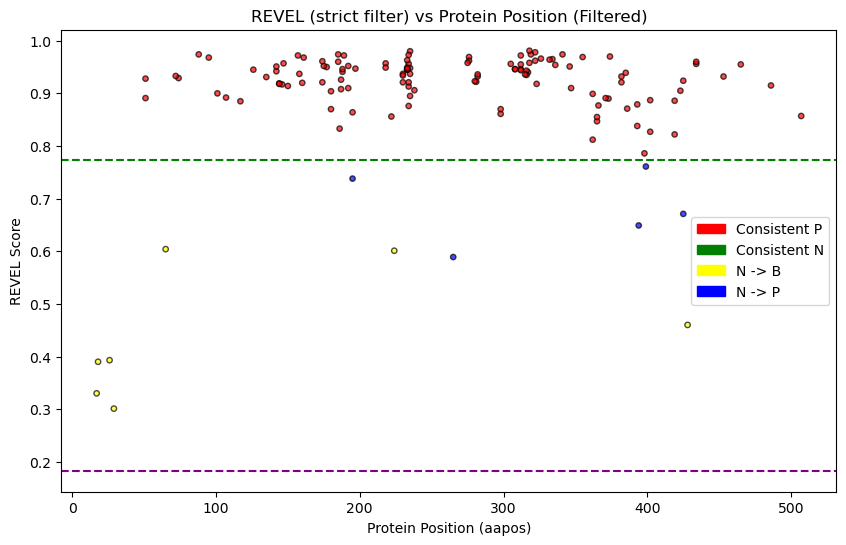

/var/folders/ph/j8bvp23j2x91fcm2f1km2nkh0000gn/T/ipykernel_2187/1798329570.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["color"] = df_filtered.apply(get_color, axis=1)


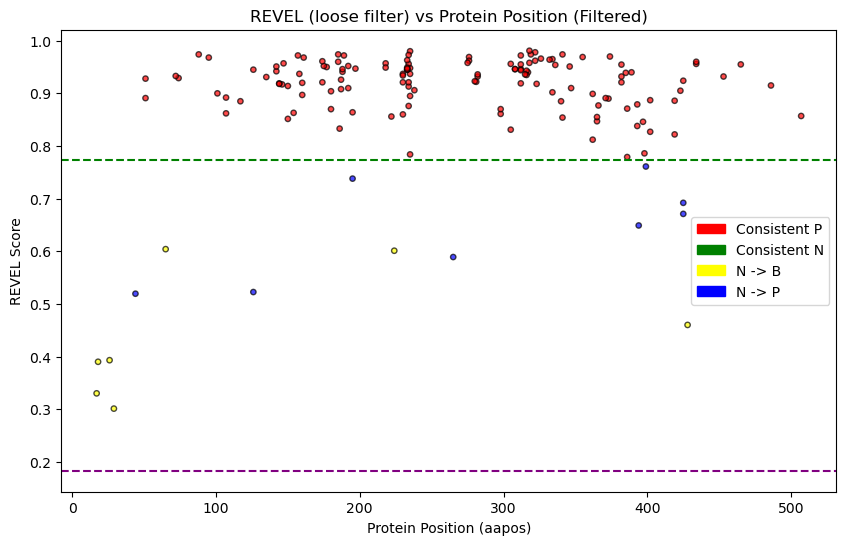

In [323]:
plot_REVEL_vs_aapos("/Users/keyuchen/FH_mutations_class_strict_label.csv", 'strict filter')
plot_REVEL_vs_aapos("/Users/keyuchen/FH_mutations_class_loose_label.csv", 'loose filter')

The universal threshold for REVEL perform quite well in classification mutation, with prediction accuracy about 90%. In one of the previous paper I read, 90% accuracy is an acceptable value. [1] From this perspective, it's unnecessary to develop new model. But if you look carefully into the data, non of the benign variant are accurately predicted.

The REVEL data in FH classification, from the graph above, did a good job in predicting pathogenic variant, however, it's extremely poor in predicting benign variant while classifying them as neutral. In the new ClinVar classification, we don't have neutral data, therefore, one way threshold is recommended by Prof. Benjamin Hall.



Reference:

[1] [[Y. Tian et al., “REVEL and BayesDel outperform other in silico meta-predictors for clinical variant classification,” Scientific Reports, vol. 9, no. 1, Sep. 2019, doi: 10.1038/s41598-019-49224-8.]](https://www.nature.com/articles/s41598-019-49224-8)


=== Strict Filter ===
Total points: 707
Total points within range (0.183 - 0.773): 354 (50.07%)
Total 'CCP' points (red): 98, Within range: 38 (38.78%)
Total 'VUS' points (black): 609, Within range: 316 (51.89%)


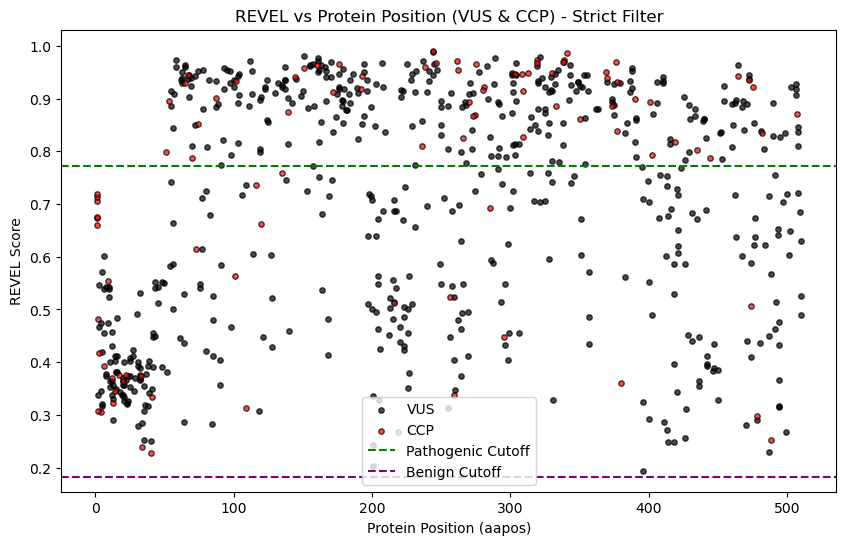


=== Loose Filter ===
Total points: 783
Total points within range (0.183 - 0.773): 400 (51.09%)
Total 'CCP' points (red): 98, Within range: 38 (38.78%)
Total 'VUS' points (black): 685, Within range: 362 (52.85%)


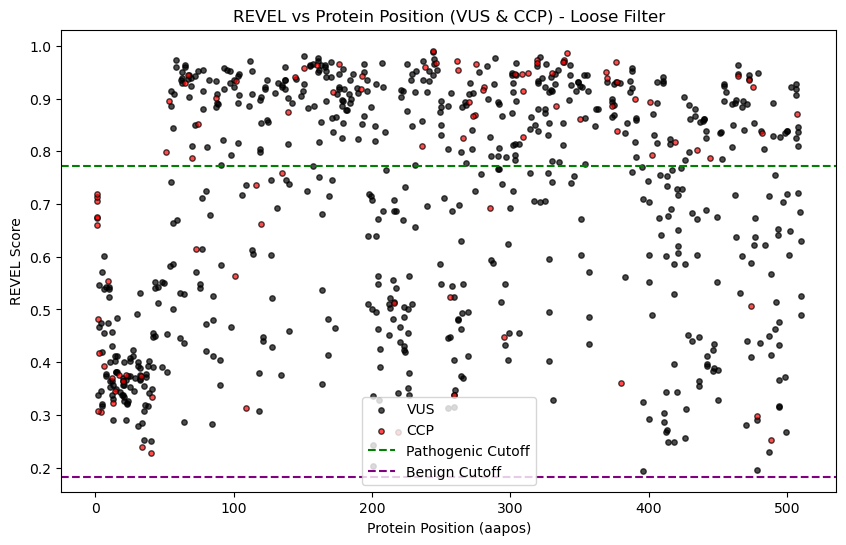

In [14]:
def plot_VUS_CCP_REVEL_vs_aapos_with_stats(file_path, title):
    """
    Plots REVEL values against protein position (aapos) while keeping only "VUS" and "CCP"
    in ClinVar_classification, and calculates basic statistics including percentages.

    Parameters:
        file_path (str): Path to the CSV file.
        title (str): Title identifier for the plot.
    """
    # Load the dataset
    df = pd.read_csv(file_path)

    # Keep only rows where ClinVar_classification is "VUS" or "CCP"
    df_filtered = df[df["ClinVar_classification"].isin(["VUS", "CCP"])]

    # Separate VUS and CCP for color mapping
    df_vus = df_filtered[df_filtered["ClinVar_classification"] == "VUS"]
    df_ccp = df_filtered[df_filtered["ClinVar_classification"] == "CCP"]

    # Define REVEL threshold range
    lower_threshold = 0.183
    upper_threshold = 0.773

    # Count points within the range
    total_within_range = df_filtered[
        (df_filtered["REVEL_score"] >= lower_threshold) & (df_filtered["REVEL_score"] <= upper_threshold)
    ].shape[0]
    
    vus_within_range = df_vus[
        (df_vus["REVEL_score"] >= lower_threshold) & (df_vus["REVEL_score"] <= upper_threshold)
    ].shape[0]

    ccp_within_range = df_ccp[
        (df_ccp["REVEL_score"] >= lower_threshold) & (df_ccp["REVEL_score"] <= upper_threshold)
    ].shape[0]

    # Calculate percentages
    total_points = len(df_filtered)
    total_percentage = (total_within_range / total_points) * 100 if total_points > 0 else 0
    vus_percentage = (vus_within_range / len(df_vus)) * 100 if len(df_vus) > 0 else 0
    ccp_percentage = (ccp_within_range / len(df_ccp)) * 100 if len(df_ccp) > 0 else 0

    # Print statistics
    print(f"\n=== {title} ===")
    print(f"Total points: {total_points}")
    print(f"Total points within range ({lower_threshold} - {upper_threshold}): {total_within_range} ({total_percentage:.2f}%)")
    print(f"Total 'CCP' points (red): {len(df_ccp)}, Within range: {ccp_within_range} ({ccp_percentage:.2f}%)")
    print(f"Total 'VUS' points (black): {len(df_vus)}, Within range: {vus_within_range} ({vus_percentage:.2f}%)")

    # Plot the graph
    plt.figure(figsize=(10, 6))
    plt.scatter(df_vus["aapos"], df_vus["REVEL_score"], color="black", alpha=0.7, edgecolors="k", label="VUS", s=15)
    plt.scatter(df_ccp["aapos"], df_ccp["REVEL_score"], color="red", alpha=0.7, edgecolors="k", label="CCP", s=15)

    # Add threshold lines
    plt.axhline(y=upper_threshold, color="green", linestyle="--", label="Pathogenic Cutoff")
    plt.axhline(y=lower_threshold, color="purple", linestyle="--", label="Benign Cutoff")

    # Labels and title
    plt.xlabel("Protein Position (aapos)")
    plt.ylabel("REVEL Score")
    plt.title(f"REVEL vs Protein Position (VUS & CCP) - {title}")

    # Show legend
    plt.legend()

    # Show plot
    plt.show()

# Run for both strict and loose datasets
plot_VUS_CCP_REVEL_vs_aapos_with_stats("/Users/keyuchen/FH_mutations_class_strict_label.csv", 'Strict Filter')
plot_VUS_CCP_REVEL_vs_aapos_with_stats("/Users/keyuchen/FH_mutations_class_loose_label.csv", 'Loose Filter')

In the code above, I investigate the value of VUS and CCP, as my original idea is to assign 50% possibility to be pathogenic for VUS adn CCP in later potential new model, i.e., ordinal regression model. This shows it's a wise choice to avoid using any VUS or CCP values.

##### BayesDel

In [15]:
import pandas as pd

def evaluate_BayesDel_classification(file_path):
    """
    Evaluates the accuracy of BayesDel classification (both MaxAF and WithoutAF) 
    compared to ClinVar classification while filtering only "P" and "B".

    Parameters:
        file_path (str): Path to the input CSV file.

    Prints:
        - Match counts
        - Match ratio
        - Unique misclassification pairs
    """
    df = pd.read_csv(file_path)

    # Filter rows where ClinVar_classification is "P" or "B"
    df_filtered = df[df["ClinVar_classification"].isin(["P", "B"])]

    # Count matches for BayesDel with MaxAF
    matches_maxaf = (df_filtered["BayesDel_classification_addAF"] == df_filtered["ClinVar_classification"]).sum()
    
    # Count matches for BayesDel without MaxAF
    matches_withoutaf = (df_filtered["BayesDel_classification_noAF"] == df_filtered["ClinVar_classification"]).sum()
    
    total = len(df_filtered)
    
    # Avoid division by zero
    ratio_maxaf = matches_maxaf / total if total > 0 else 0
    ratio_withoutaf = matches_withoutaf / total if total > 0 else 0

    # Find unique difference pairs for MaxAF
    differences_maxaf = df_filtered[df_filtered["BayesDel_classification_addAF"] != df_filtered["ClinVar_classification"]]
    unique_differences_maxaf = differences_maxaf.groupby(["BayesDel_classification_addAF", "ClinVar_classification"]).size().reset_index(name="count")

    # Find unique difference pairs for WithoutAF
    differences_withoutaf = df_filtered[df_filtered["BayesDel_classification_noAF"] != df_filtered["ClinVar_classification"]]
    unique_differences_withoutaf = differences_withoutaf.groupby(["BayesDel_classification_noAF", "ClinVar_classification"]).size().reset_index(name="count")

    # Print results
    print(f"\n=== BayesDel Classification Evaluation ===")
    print(f"Total Considered Rows: {total}")
    print(f"Matches (MaxAF): {matches_maxaf}, Match Ratio (MaxAF): {ratio_maxaf:.4f}")
    print(f"Matches (WithoutAF): {matches_withoutaf}, Match Ratio (WithoutAF): {ratio_withoutaf:.4f}")

    # Print unique difference pairs
    print("\nUnique Difference Pairs (MaxAF):")
    print(unique_differences_maxaf.to_string(index=False))

    print("\nUnique Difference Pairs (WithoutAF):")
    print(unique_differences_withoutaf.to_string(index=False))

In [16]:
evaluate_BayesDel_classification("/Users/keyuchen/FH_mutations_class_strict_label.csv")


=== BayesDel Classification Evaluation ===
Total Considered Rows: 134
Matches (MaxAF): 132, Match Ratio (MaxAF): 0.9851
Matches (WithoutAF): 132, Match Ratio (WithoutAF): 0.9851

Unique Difference Pairs (MaxAF):
BayesDel_classification_addAF ClinVar_classification  count
                            B                      P      1
                            P                      B      1

Unique Difference Pairs (WithoutAF):
BayesDel_classification_noAF ClinVar_classification  count
                           P                      B      2


In [18]:
evaluate_BayesDel_classification("/Users/keyuchen/FH_mutations_class_loose_label.csv")


=== BayesDel Classification Evaluation ===
Total Considered Rows: 152
Matches (MaxAF): 150, Match Ratio (MaxAF): 0.9868
Matches (WithoutAF): 150, Match Ratio (WithoutAF): 0.9868

Unique Difference Pairs (MaxAF):
BayesDel_classification_addAF ClinVar_classification  count
                            B                      P      1
                            P                      B      1

Unique Difference Pairs (WithoutAF):
BayesDel_classification_noAF ClinVar_classification  count
                           P                      B      2


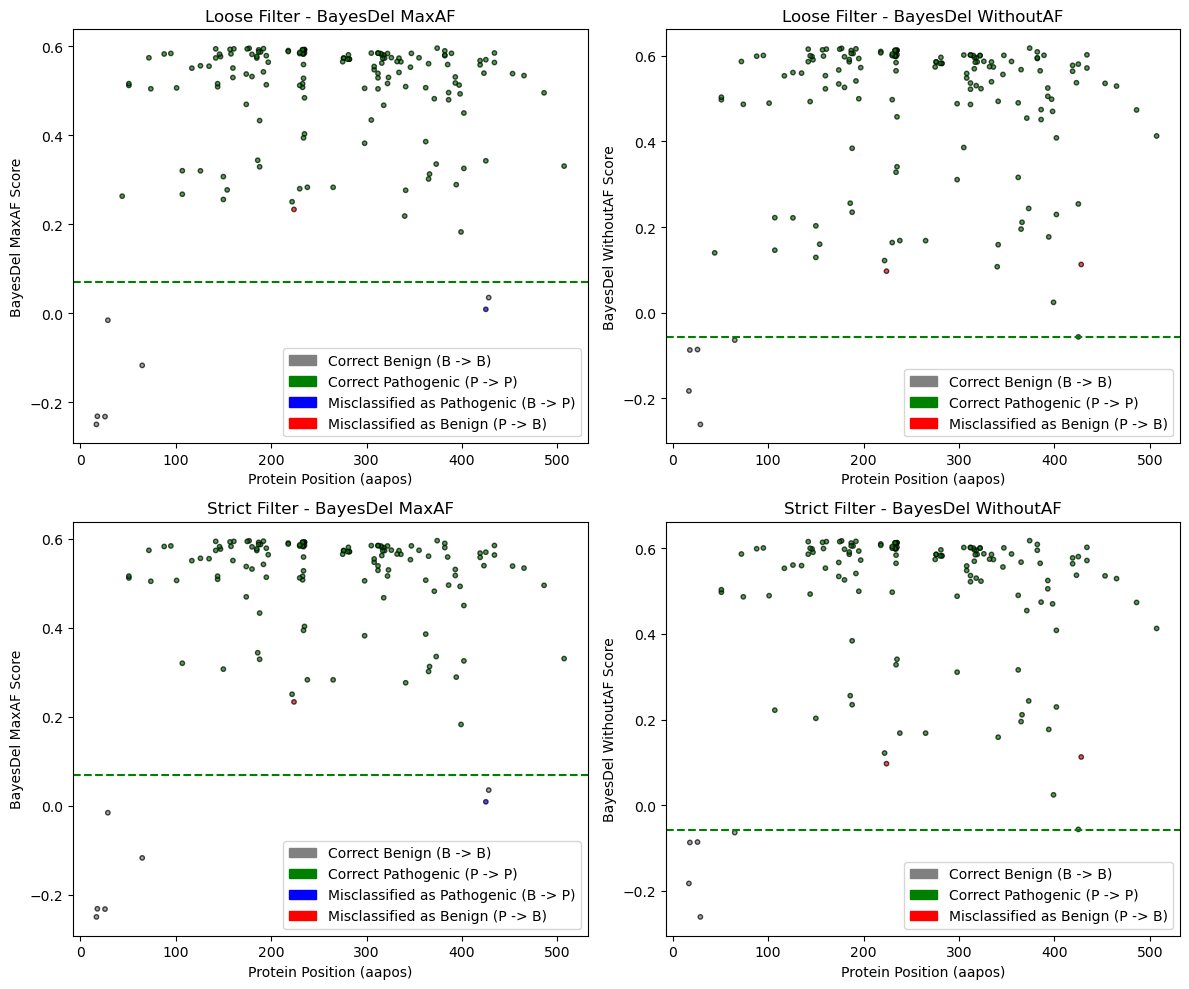

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_BayesDel_vs_aapos_subplot(ax, file_path, score_type="addAF", title_suffix=""):
    """
    Plots BayesDel scores against protein position (aapos) on the given axes.
    
    Parameters:
        ax (matplotlib.axes.Axes): The axes to plot on.
        file_path (str): Path to the CSV file.
        score_type (str): "addAF" or "noAF" indicating which BayesDel score to plot.
        title_suffix (str): Extra string to append to the title.
    """
    # Load the dataset
    df = pd.read_csv(file_path)

    # Filter out rows where ClinVar_classification is "VUS" or "CCP"
    df_filtered = df[~df["ClinVar_classification"].isin(["VUS", "CCP"])].copy()

    # Select the appropriate score column, classification, cutoff, etc.
    if score_type == "addAF":
        score_column = "BayesDel_addAF_score"
        # Assuming we have a corresponding classification column
        class_column = "BayesDel_classification_addAF" if "BayesDel_classification_addAF" in df_filtered.columns else "BayesDel_classification"
        cutoff = 0.0692655  # Example cutoff for addAF
        ylabel = "BayesDel MaxAF Score"
        horizontal_line = ax.axhline(y=cutoff, color="green", linestyle="--", label="Pathogenic Cutoff (MaxAF)")
        # Define legend for four cases
        legend_patches = [
            mpatches.Patch(color="gray", label="Correct Benign (B -> B)"),
            mpatches.Patch(color="green", label="Correct Pathogenic (P -> P)"),
            mpatches.Patch(color="blue", label="Misclassified as Pathogenic (B -> P)"),
            mpatches.Patch(color="red", label="Misclassified as Benign (P -> B)")
        ]
    elif score_type == "noAF":
        score_column = "BayesDel_noAF_score"
        # Use a classification column (fallback to addAF if no noAF exists)
        class_column = "BayesDel_classification_noAF" if "BayesDel_classification_noAF" in df_filtered.columns else "BayesDel_classification"
        cutoff = -0.0570105  # Example cutoff for noAF
        ylabel = "BayesDel WithoutAF Score"
        horizontal_line = ax.axhline(y=cutoff, color="green", linestyle="--", label="Pathogenic Cutoff (WithoutAF)")
        # Define legend for three cases
        legend_patches = [
            mpatches.Patch(color="gray", label="Correct Benign (B -> B)"),
            mpatches.Patch(color="green", label="Correct Pathogenic (P -> P)"),
            mpatches.Patch(color="red", label="Misclassified as Benign (P -> B)")
        ]
    else:
        raise ValueError("score_type must be either 'addAF' or 'noAF'.")

    # Define a color mapping function based on classification
    def get_color(row):
        if row[class_column] == "B" and row["ClinVar_classification"] == "B":
            return "gray"   # Correct Benign (B -> B)
        elif row[class_column] == "P" and row["ClinVar_classification"] == "P":
            return "green"  # Correct Pathogenic (P -> P)
        elif row[class_column] == "B" and row["ClinVar_classification"] == "P":
            return "blue"   # Misclassified as Pathogenic (B -> P)
        elif row[class_column] == "P" and row["ClinVar_classification"] == "B":
            return "red"    # Misclassified as Benign (P -> B)
        return "black"      # Fallback

    df_filtered["color"] = df_filtered.apply(get_color, axis=1)

    # Create the scatter plot using smaller markers
    ax.scatter(df_filtered["aapos"], df_filtered[score_column],
               c=df_filtered["color"], alpha=0.7, edgecolors="k", s=10)
    
    ax.set_xlabel("Protein Position (aapos)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title_suffix}")

    # Add legend to the axes
    ax.legend(handles=legend_patches)

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot for loose filter with addAF (top-left)
plot_BayesDel_vs_aapos_subplot(axs[0, 0],
                               file_path="/Users/keyuchen/FH_mutations_class_loose_label.csv",
                               score_type="addAF",
                               title_suffix="Loose Filter - BayesDel MaxAF")

# Plot for loose filter without AF (top-right)
plot_BayesDel_vs_aapos_subplot(axs[0, 1],
                               file_path="/Users/keyuchen/FH_mutations_class_loose_label.csv",
                               score_type="noAF",
                               title_suffix="Loose Filter - BayesDel WithoutAF")

# Plot for strict filter with addAF (bottom-left)
plot_BayesDel_vs_aapos_subplot(axs[1, 0],
                               file_path="/Users/keyuchen/FH_mutations_class_strict_label.csv",
                               score_type="addAF",
                               title_suffix="Strict Filter - BayesDel MaxAF")

# Plot for strict filter without AF (bottom-right)
plot_BayesDel_vs_aapos_subplot(axs[1, 1],
                               file_path="/Users/keyuchen/FH_mutations_class_strict_label.csv",
                               score_type="noAF",
                               title_suffix="Strict Filter - BayesDel WithoutAF")

plt.tight_layout()
plt.show()



#### How consistence is two data?

This part is done by Linhua

#### General data visualization

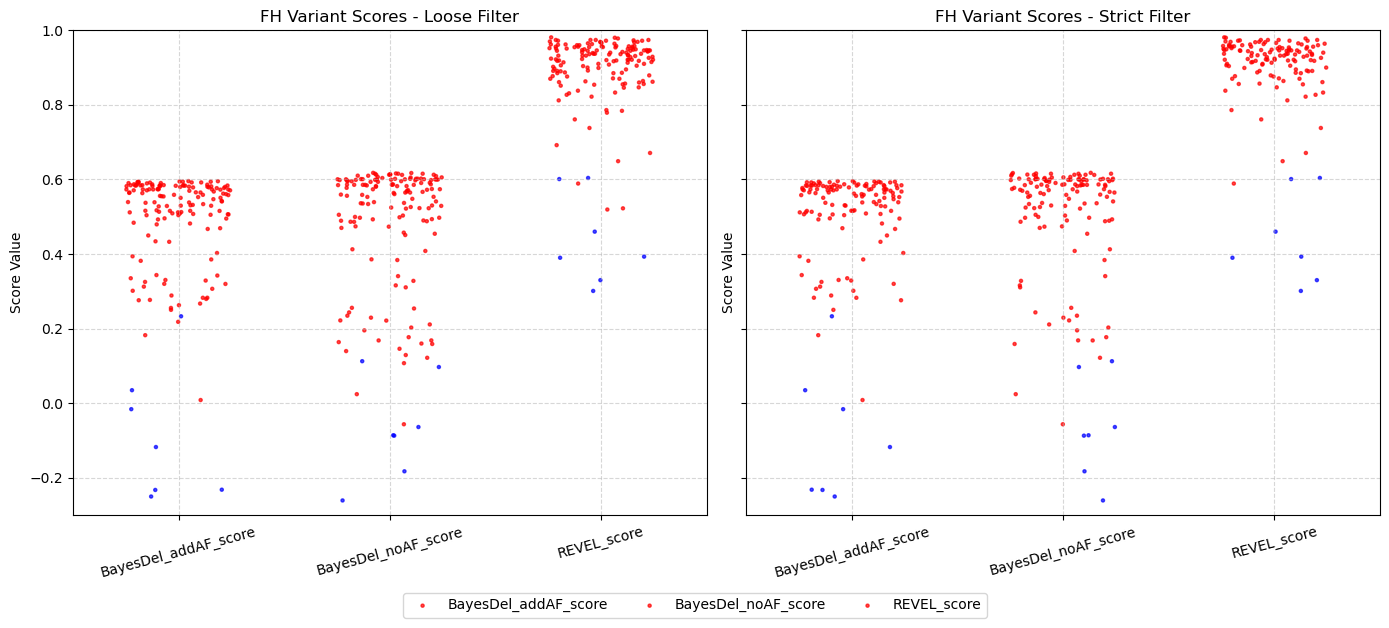

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File paths for loose and strict filters (UPDATE THESE)
loose_file = "/Users/keyuchen/FH_mutations_class_loose_label.csv"  # <-- Change this
strict_file = "/Users/keyuchen/FH_mutations_class_strict_label.csv"  # <-- Change this

# Load datasets
df_loose = pd.read_csv(loose_file)
df_strict = pd.read_csv(strict_file)

# Ensure necessary columns exist
expected_cols = {"BayesDel_addAF_score", "BayesDel_noAF_score", "REVEL_score", "ClinVar_classification"}
for df, name in zip([df_loose, df_strict], ["loose", "strict"]):
    if not expected_cols.issubset(df.columns):
        raise ValueError(f"{name.capitalize()} dataset is missing required columns: {expected_cols - set(df.columns)}")

# Filter out values other than 'P' and 'B' in 'ClinVar_classification'
df_loose = df_loose[df_loose["ClinVar_classification"].isin(["P", "B"])]
df_strict = df_strict[df_strict["ClinVar_classification"].isin(["P", "B"])]

# Function to plot the three score distributions
def plot_scores(ax, df, filter_type):
    # Define x positions for the three scores with more horizontal spacing
    x_positions = [1, 3, 5]  # Spread out positions more
    labels = ["BayesDel_addAF_score", "BayesDel_noAF_score", "REVEL_score"]
    
    # Apply jitter to avoid clustering (small horizontal shift)
    jitter_strength = 0.5  # Adjust this to control spread
    np.random.seed(42)  # For reproducibility
    
    for i, col in enumerate(labels):
        jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(df))  # Add horizontal noise
        
        # Assign colors based on ClinVar_classification
        colors = df["ClinVar_classification"].map(lambda x: 'red' if x == 'P' else ('blue' if x == 'B' else 'black'))
        
        ax.scatter(x_positions[i] + jitter, df[col], alpha=0.7, label=labels[i] if filter_type == "loose" else "", s=5, c=colors)

    # Labels and formatting
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("Score Value")
    ax.set_title(f"FH Variant Scores - {filter_type.capitalize()} Filter")
    ax.set_ylim(-0.3, 1)  # Ensures y-axis is from -0.3 to 1
    ax.set_xlim(0, 6)  # Expands x-range for better spacing
    ax.grid(True, linestyle="--", alpha=0.5)

# Create two subplots in one row
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Loose Filter
plot_scores(axes[0], df_loose, "loose")

# Plot Strict Filter
plot_scores(axes[1], df_strict, "strict")

# Add legend only once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()


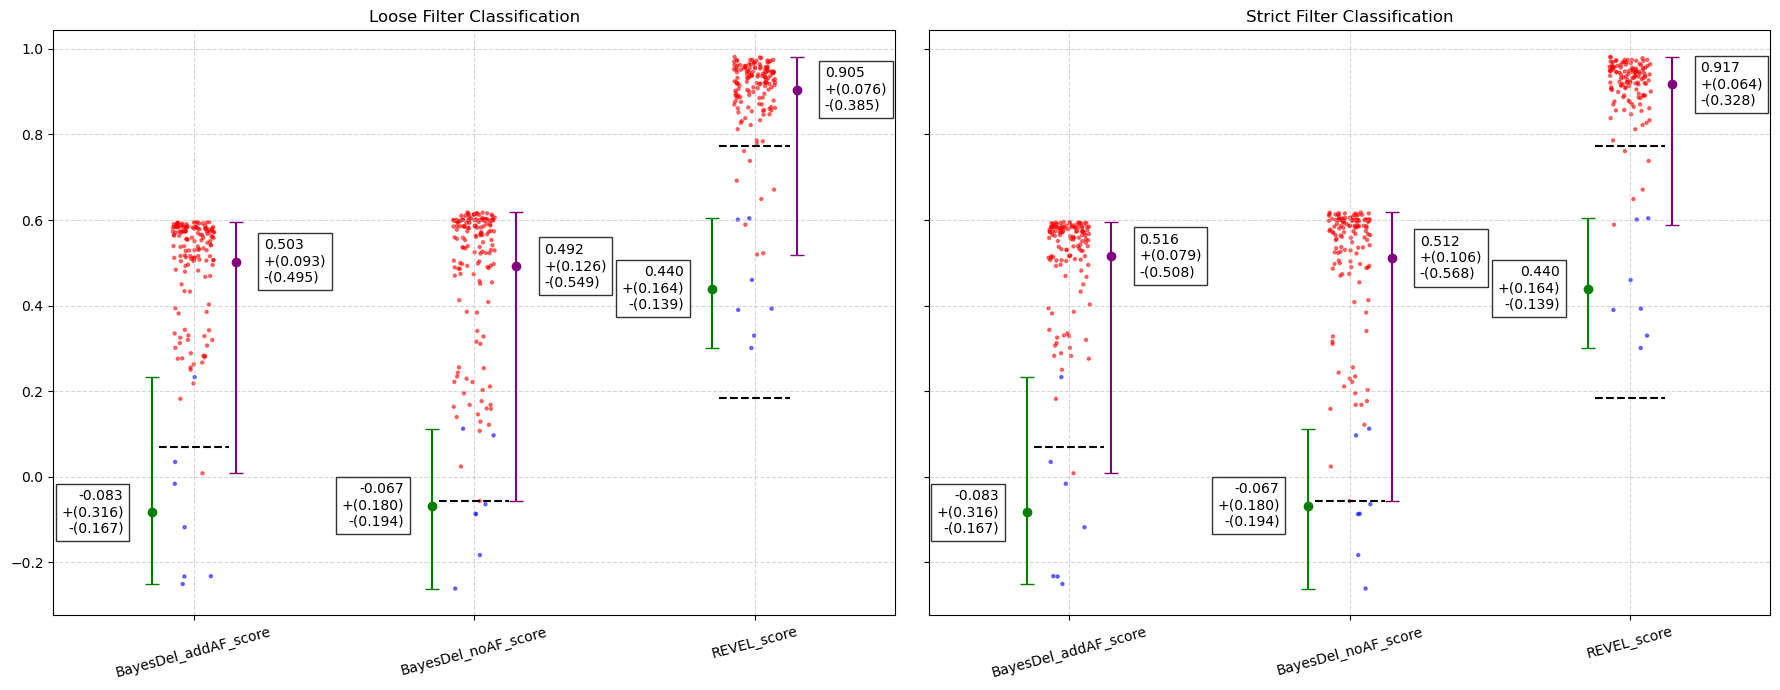

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File paths for loose and strict filters (UPDATE THESE)
loose_file = "/Users/keyuchen/FH_mutations_class_loose_label.csv"  # <-- Change this
strict_file = "/Users/keyuchen/FH_mutations_class_strict_label.csv"  # <-- Change this

# Load datasets
df_loose = pd.read_csv(loose_file)
df_strict = pd.read_csv(strict_file)

# Ensure necessary columns exist
expected_cols = {"BayesDel_addAF_score", "BayesDel_noAF_score", "REVEL_score", "ClinVar_classification"}
for df, name in zip([df_loose, df_strict], ["loose", "strict"]):
    if not expected_cols.issubset(df.columns):
        raise ValueError(f"{name.capitalize()} dataset is missing required columns: {expected_cols - set(df.columns)}")

# Filter out values other than 'P' and 'B' in 'ClinVar_classification'
df_loose = df_loose[df_loose["ClinVar_classification"].isin(["P", "B"])]
df_strict = df_strict[df_strict["ClinVar_classification"].isin(["P", "B"])]

# Universal cutoff values based on the provided image
cutoff_values = {
    "BayesDel_addAF_score": 0.0693,
    "BayesDel_noAF_score": -0.0570,
    "REVEL_score": [0.773, 0.184]
}

# Function to plot the three score distributions with mean and range bars
def plot_scores(ax, df, filter_type):
    # Define x positions for the three scores
    x_positions = [2, 6, 10]
    labels = ["BayesDel_addAF_score", "BayesDel_noAF_score", "REVEL_score"]
    
    # Apply jitter to avoid clustering (small horizontal shift)
    jitter_strength = 0.3  # Adjust this to control spread
    np.random.seed(42)  # For reproducibility
    
    for i, col in enumerate(labels):
        benign = df[df["ClinVar_classification"] == "B"][col]
        pathogenic = df[df["ClinVar_classification"] == "P"][col]
        
        # Prevent points overlapping
        jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(df))
        colors = df["ClinVar_classification"].map(lambda x: 'red' if x == 'P' else 'blue')
        ax.scatter(x_positions[i] + jitter, df[col], alpha=0.5, s=5, c=colors)
        
        if not benign.empty:
            benign_mean = benign.mean()
            benign_min = benign.min()
            benign_max = benign.max()
            ax.errorbar(x_positions[i] - 0.6, benign_mean, yerr=[[benign_mean - benign_min], [benign_max - benign_mean]], fmt='o', color='green', capsize=5, label=labels[i] if filter_type == "loose" else "")
            ax.text(x_positions[i] - 1, benign_mean, f"{benign_mean:.3f}\n+({benign_max - benign_mean:.3f})\n-({benign_mean - benign_min:.3f})", ha='right', va='center', fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))
        
        if not pathogenic.empty:
            pathogenic_mean = pathogenic.mean()
            pathogenic_min = pathogenic.min()
            pathogenic_max = pathogenic.max()
            ax.errorbar(x_positions[i] + 0.6, pathogenic_mean, yerr=[[pathogenic_mean - pathogenic_min], [pathogenic_max - pathogenic_mean]], fmt='o', color='purple', capsize=5)
            ax.text(x_positions[i] + 1, pathogenic_mean, f"{pathogenic_mean:.3f}\n+({pathogenic_max - pathogenic_mean:.3f})\n-({pathogenic_mean - pathogenic_min:.3f})", ha='left', va='center', fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))
        
        # Add universal cutoff line(s)
        if col in cutoff_values:
            cutoff_vals = cutoff_values[col]
            if isinstance(cutoff_vals, list):  # If multiple cutoffs exist
                for cutoff in cutoff_vals:
                    ax.hlines(y=cutoff, xmin=x_positions[i] - 0.5, xmax=x_positions[i] + 0.5, colors='black', linestyles='dashed', linewidth=1.5)
            else:
                ax.hlines(y=cutoff_vals, xmin=x_positions[i] - 0.5, xmax=x_positions[i] + 0.5, colors='black', linestyles='dashed', linewidth=1.5)
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_xlim(0, 12)  # Ensure full display of error bars and annotations
    ax.grid(True, linestyle="--", alpha=0.5)

# Create two subplots in one row
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot Loose Filter
plot_scores(axes[0], df_loose, "loose")
axes[0].set_title("Loose Filter Classification")

# Plot Strict Filter
plot_scores(axes[1], df_strict, "strict")
axes[1].set_title("Strict Filter Classification")

# Adjust layout to avoid text cutoff
plt.tight_layout()
plt.show()

#### Model 2: Logistic regression

One reason to do this is that, for FH gene, it might be more accurate to develop an gene level threshold for BayesDel meta predictor.


Logistic regression = linear regression + sigmoid function.

for the linear regression, we can select the polynomial order. i.e., 1st order means simple linear regression models, while second order includes the quadratic term.


Firth logistic regression is recommended by previous work [1]. this is a modification of standard logistic regression to reduce bias, especially dealing with small sample sizes and rare events. Prevent overfitting and infinite coefficient estimates -> fifth method add penalty term to log-likelihood function.

Reference:

[1] [Q. Zheng et al., “Exome-Wide Association study reveals several susceptibility genes and pathways associated with acute coronary syndromes in Han Chinese,” Frontiers in Genetics, vol. 11, Apr. 2020, doi: 10.3389/fgene.2020.00336.](https://www.jacc.org/doi/10.1016/j.jacc.2016.11.056)


Let's first plot the logistic regression value for display before fitting with the curve.

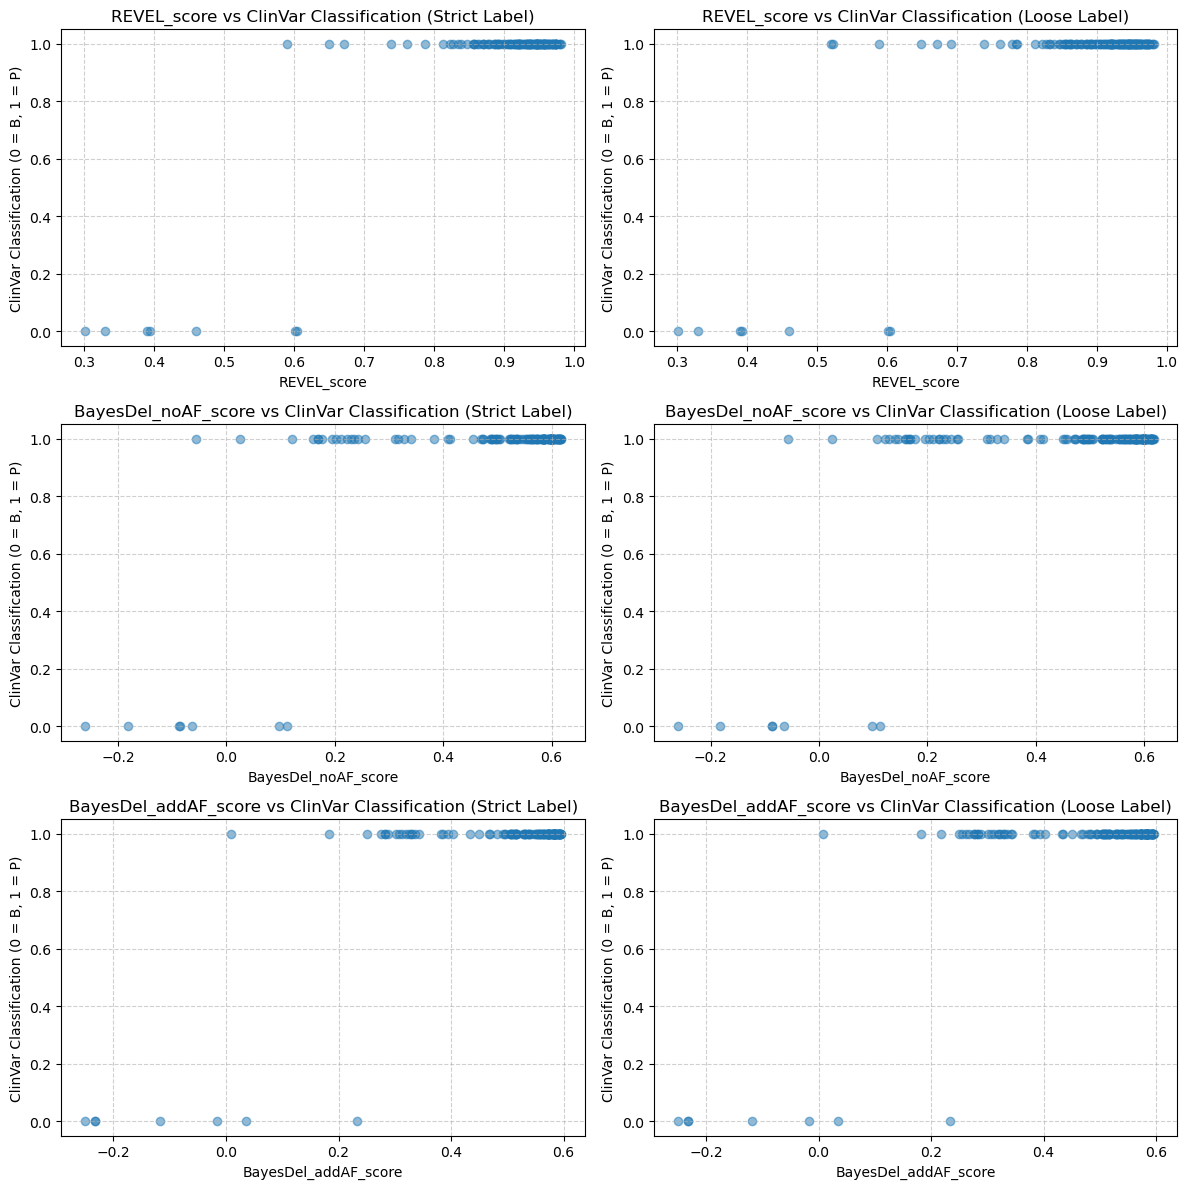

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

def logistic_regression_comparison(strict_file, loose_file, input_scores):
    """
    Compares logistic regression input scores between strict and loose classification filters.

    Parameters:
    strict_file (str): Path to the strict classification file.
    loose_file (str): Path to the loose classification file.
    input_scores (list): List of input score column names (e.g., ["REVEL_score", "BayesDel_noAF_score", "BayesDel_addAF_score"])
    """
    
    # Load datasets
    df_strict = pd.read_csv(strict_file)
    df_loose = pd.read_csv(loose_file)

    # Prepare figure with subplots
    fig, axes = plt.subplots(len(input_scores), 2, figsize=(12, 4 * len(input_scores)))

    for i, score in enumerate(input_scores):
        for j, (df, label) in enumerate(zip([df_strict, df_loose], ["Strict", "Loose"])):
            # Filter out VUS and CCP classifications
            df_filtered = df[~df["ClinVar_classification"].isin(["VUS", "CCP"])].copy()

            # Convert classification to binary labels
            df_filtered["ClinVar_classification"] = df_filtered["ClinVar_classification"].map({"B": 0, "P": 1})

            # Drop missing values
            df_filtered = df_filtered.dropna(subset=["ClinVar_classification", score])

            # Scatter plot
            ax = axes[i, j]
            ax.scatter(df_filtered[score], df_filtered["ClinVar_classification"], alpha=0.5, marker='o')
            ax.set_xlabel(score)
            ax.set_ylabel("ClinVar Classification (0 = B, 1 = P)")
            ax.set_title(f"{score} vs ClinVar Classification ({label} Label)")
            ax.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

# Example usage:
logistic_regression_comparison(
    "/Users/keyuchen/FH_mutations_class_strict_label.csv",
    "/Users/keyuchen/FH_mutations_class_loose_label.csv",
    ["REVEL_score", "BayesDel_noAF_score", "BayesDel_addAF_score"]
)

In [311]:
### this cell is used to illustrated the difference with the firth logistic regression and standard
### logistic regression in terms of code

# log_reg = sm.Logit(logreg_y, logreg_x).fit(method = "newton", skip_hessian = 0)

##### Theory

Understand how Firth logistic regression is used in our code.

Functions:
- logistic regression model
$$P(y=1 \mid X)=\frac{1}{1+e^{-\beta^T X}}$$

- log-likelihood function (standard SLE) [1]
$$
\ell(\beta)=\sum_{i=1}^n\left[y_i \log P\left(y_i\right)+\left(1-y_i\right) \log \left(1-P\left(y_i\right)\right)\right]
$$

- Fisher information matrix, $w$ is diagonal weight matrix based on predicted probabilities. [2]
$$
I(\beta)=X^T W X, \quad W=\operatorname{diag}\left(p_i\left(1-p_i\right)\right)
$$ 

- firth's penalized log-likelihood [2]
$$
\ell^*(\beta)=\ell(\beta)+\frac{1}{2} \log |I(\beta)|
$$


- optimization (numerical methods like BFGS)
  - This helps to find the value of $\beta$
  - Method 1: Newton Raphson Method: iterates until convergence
$$
\beta^{(t+1)}=\beta^{(t)}-\left[\frac{\partial^2 \ell^*(\beta)}{\partial \beta^2}\right]^{-1} \frac{\partial \ell^*(\beta)}{\partial \beta}
$$
  - Method 2: BFGS (similar to method 1 but faster and more stable)



Workflows for $\beta$ estimation:
- initialize $\beta$ using zero vector
- compute penalized log-likelihood
- compute log-likelihood first + second derivate with respect to $\beta$
- iterative numerical method (Newton Raphson Method / BFGS)
- extract final estimated $\beta$ value.


Reference source:

[1] [Taboga, Marco (2021). "Logistic regression - Maximum Likelihood Estimation", Lectures on probability theory and mathematical statistics. Kindle Direct Publishing. Online appendix. https://www.statlect.com/fundamentals-of-statistics/logistic-model-maximum-likelihood.](https://www.statlect.com/fundamentals-of-statistics/logistic-model-maximum-likelihood)

[2] [D. Firth, “Bias reduction of maximum likelihood estimates,” Biometrika, vol. 80, no. 1, pp. 27–38, Jan. 1993, doi: 10.1093/biomet/80.1.27.](https://www2.stat.duke.edu/~scs/Courses/Stat376/Papers/GibbsFieldEst/BiasReductionMLE.pdf)


##### Code

In [24]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt


      fun: 5.736449415771553
 hess_inv: array([[9.83274416, 3.63613232],
       [3.63613232, 1.46809816]])
      jac: array([-1.54972076e-06,  2.98023224e-06])
  message: 'Optimization terminated successfully.'
     nfev: 66
      nit: 18
     njev: 22
   status: 0
  success: True
        x: array([9.33457313, 3.49488257])
AUC: 0.9941
Optimal probability cutoff: 0.9471
Sensitivity (TPR): 0.9793
Specificity (TNR): 1.0000
Accuracy: 0.9803
Optimal REVEL_score cutoff: 0.648828


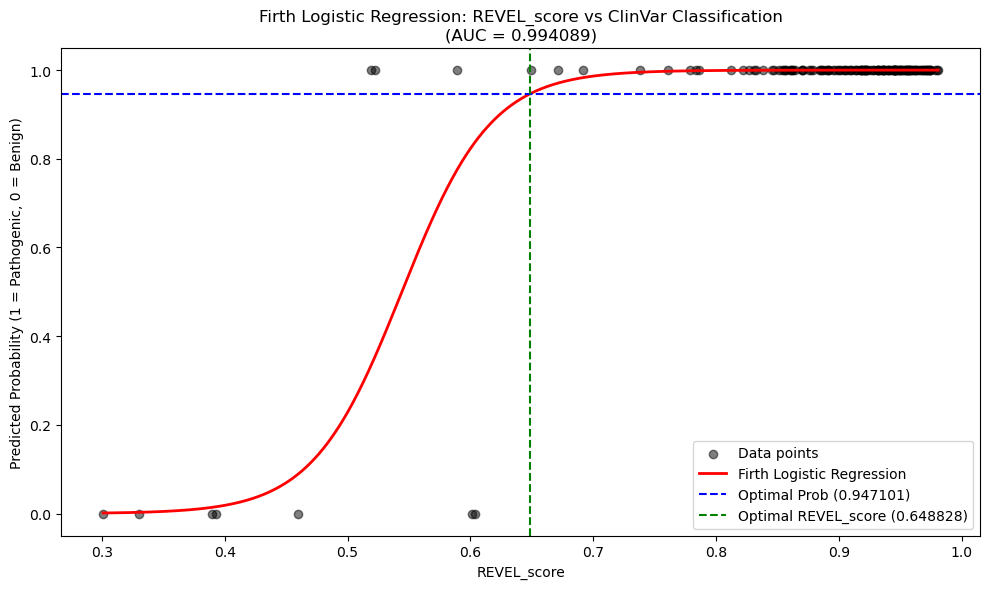

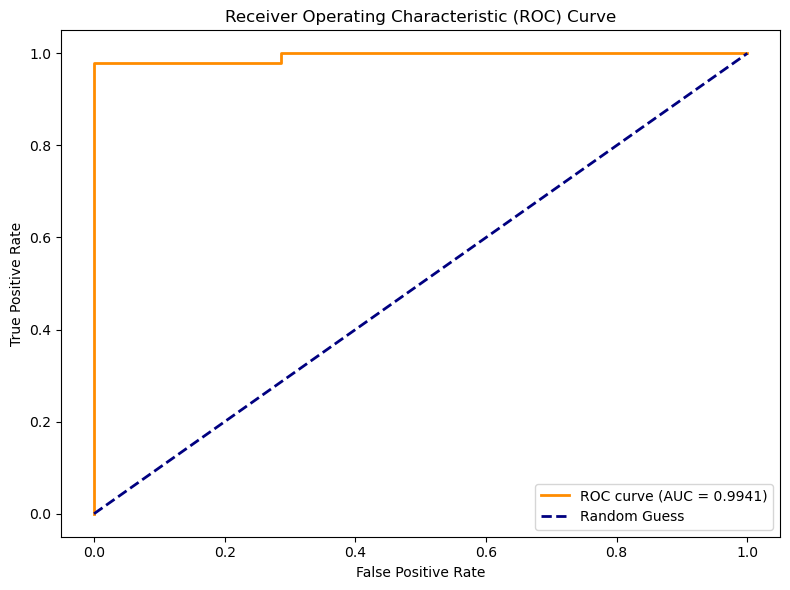

(array([9.33457313, 3.49488257]), 0.9471006890072236, 0.6488278278278278)

In [25]:
def firth_loss(beta, X, y):
    """
    Computes the penalized log-likelihood for Firth logistic regression.
    """
    logits = np.dot(X, beta)
    p = 1 / (1 + np.exp(-logits))
    
    eps = 1e-10  #eps added to prevent the log(p) to be zero, and make it hard for later calculation.
    p = np.clip(p, eps, 1 - eps)  # Ensure probabilities stay within (0,1)
    log_likelihood = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

    # Compute log-likelihood
    # log_likelihood = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    
    # Compute penalty term (log determinant of Fisher information matrix)
    W = np.diag(p * (1 - p))
    fisher_info = X.T @ W @ X
    penalty = 0.5 * np.log(np.linalg.det(fisher_info))
    
    return -(log_likelihood - penalty)  # Negative for minimization

def fit_firth_logistic_regression(X, y):
    """
    Fits a Firth logistic regression model using penalized likelihood estimation.
    """
    X = sm.add_constant(X)  # Add intercept
    beta_init = np.zeros(X.shape[1])  # Initial coefficients
    
    # Minimize penalized log-likelihood
    result = minimize(firth_loss, beta_init, args=(X, y), method="BFGS")
    print(result)

    return result.x, X  # Return coefficients (include optimize beta values) and design matrix

def firth_logistic_regression(file_path, predictor_column):
    """
    Fits a Firth logistic regression model, computes the ROC curve, and determines the optimal threshold.
    """
    # Load dataset
    df = pd.read_csv(file_path)
    df = df[df["ClinVar_classification"].isin(["B", "P"])].copy()
    df["y"] = df["ClinVar_classification"].map({"B": 0, "P": 1})
    
    # Extract predictor variable and standardize
    x = df[predictor_column].values
    y = df["y"].values
    x_mean, x_std = np.mean(x), np.std(x)
    x_stdized = (x - x_mean) / x_std
    
    # Fit Firth logistic regression
    beta, X_design = fit_firth_logistic_regression(x_stdized, y)
    
    # Compute predicted probabilities
    logits = np.dot(X_design, beta)
    y_probs = 1 / (1 + np.exp(-logits))
    
    # Compute AUC
    auc_val = roc_auc_score(y, y_probs)
    print(f"AUC: {auc_val:.4f}")
    
    # Compute ROC curve and determine optimal threshold (Youden's index)
    fpr, tpr, thresholds = roc_curve(y, y_probs)
    youden_index = tpr - fpr
    opt_prob = thresholds[np.argmax(youden_index)]
    print(f"Optimal probability cutoff: {opt_prob:.4f}")
    
    # Compute classification metrics
    y_pred_class = (y_probs >= opt_prob).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred_class).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    print(f"Sensitivity (TPR): {sensitivity:.4f}")
    print(f"Specificity (TNR): {specificity:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    
    # Find the optimal predictor value
    x_grid = np.linspace(x.min(), x.max(), 1000)
    x_grid_std = (x_grid - x_mean) / x_std
    X_grid = sm.add_constant(x_grid_std)
    y_grid_pred = 1 / (1 + np.exp(-np.dot(X_grid, beta)))
    idx_opt = np.argmin(np.abs(y_grid_pred - opt_prob))
    opt_score = x_grid[idx_opt]
    print(f"Optimal {predictor_column} cutoff: {opt_score:.6f}")
    
    # Plot logistic regression curve
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='black', alpha=0.5, label='Data points')
    plt.plot(x_grid, y_grid_pred, color='red', linewidth=2, label='Firth Logistic Regression')
    plt.axhline(opt_prob, color='blue', linestyle='--', label=f'Optimal Prob ({opt_prob:.6f})')
    plt.axvline(opt_score, color='green', linestyle='--', label=f'Optimal {predictor_column} ({opt_score:.6f})')
    plt.xlabel(predictor_column)
    plt.ylabel("Predicted Probability (1 = Pathogenic, 0 = Benign)")
    plt.title(f"Firth Logistic Regression: {predictor_column} vs ClinVar Classification\n(AUC = {auc_val:.6f})")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {auc_val:.4f})")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    
    return beta, opt_prob, opt_score

firth_logistic_regression("/Users/keyuchen/FH_mutations_class_loose_label.csv", "REVEL_score")

Interpret the output result of our model:

- fun: final optimized loss value
- hess_inv: inverse Hessian matrix. Large coefficients suggested high uncertainty.
- jac: the derivatives of the loss function with respect to each parameter. value close to 0 indicates good approximation and ideal for MSE
- message: Confirms that the algorithm converged properly, meaning it found an optimal solution.
- nfev: (Number of function evaluations)
- njev: (Number of Jacobian evaluations)
- nit: Number of iterations (optimization steps) taken by the BFGS algorithm.
- status: 0
- success: True
- x: This is the final estimated coefficient vector (β-hat), first is the first beta, second is the final beta

      fun: -0.21652776982947763
 hess_inv: array([[19.15689311,  6.36892491],
       [ 6.36892491,  2.11742183]])
      jac: array([ 2.47359276e-06, -1.04308128e-05])
  message: 'Desired error not necessarily achieved due to precision loss.'
     nfev: 215
      nit: 24
     njev: 69
   status: 2
  success: False
        x: array([40.59502906, 17.86753907])
AUC: 0.9978
Optimal probability cutoff: 0.9974
Sensitivity (TPR): 0.9921
Specificity (TNR): 1.0000
Accuracy: 0.9925
Optimal REVEL_score cutoff: 0.648828


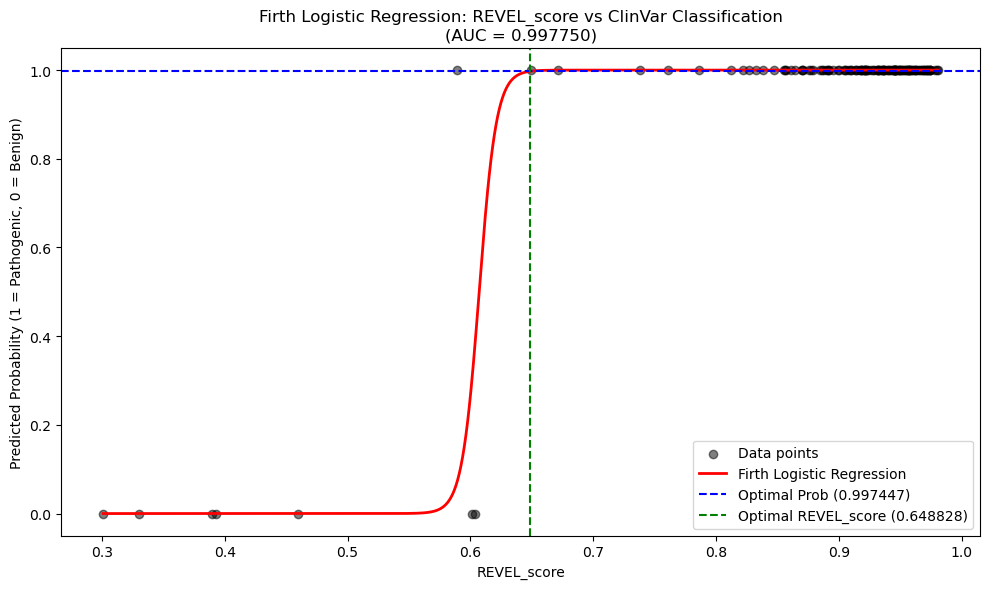

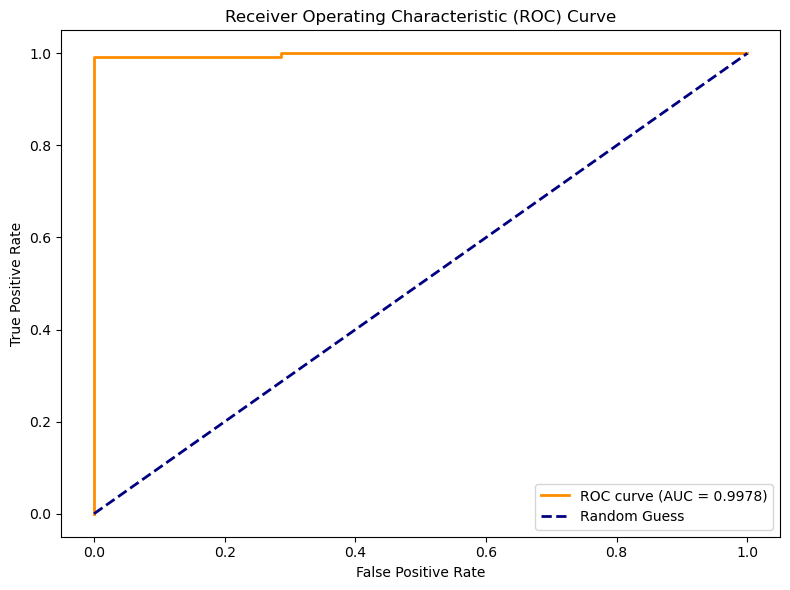

(array([40.59502906, 17.86753907]), 0.9974474688891205, 0.6488278278278278)

In [313]:
firth_logistic_regression("/Users/keyuchen/FH_mutations_class_strict_label.csv", "REVEL_score")

Notice that there are several places indicate the algo struggle to converge. Why?
- Fisher Information Matrix issue: matrix is close to singular (i.e., nearly non-invertible), the determinant may be close to zero or negative, causing instability in the penalty calculation -> indicate there is prefect separation

      fun: 7.492129140769499
 hess_inv: array([[10.52761516,  4.73859063],
       [ 4.73859063,  2.28342692]])
      jac: array([1.13248825e-06, 1.25169754e-06])
  message: 'Optimization terminated successfully.'
     nfev: 57
      nit: 18
     njev: 19
   status: 0
  success: True
        x: array([10.40262556,  4.49592   ])
AUC: 0.9951
Optimal probability cutoff: 0.9188
Sensitivity (TPR): 0.9793
Specificity (TNR): 1.0000
Accuracy: 0.9803
Optimal BayesDel_noAF_score cutoff: 0.121715


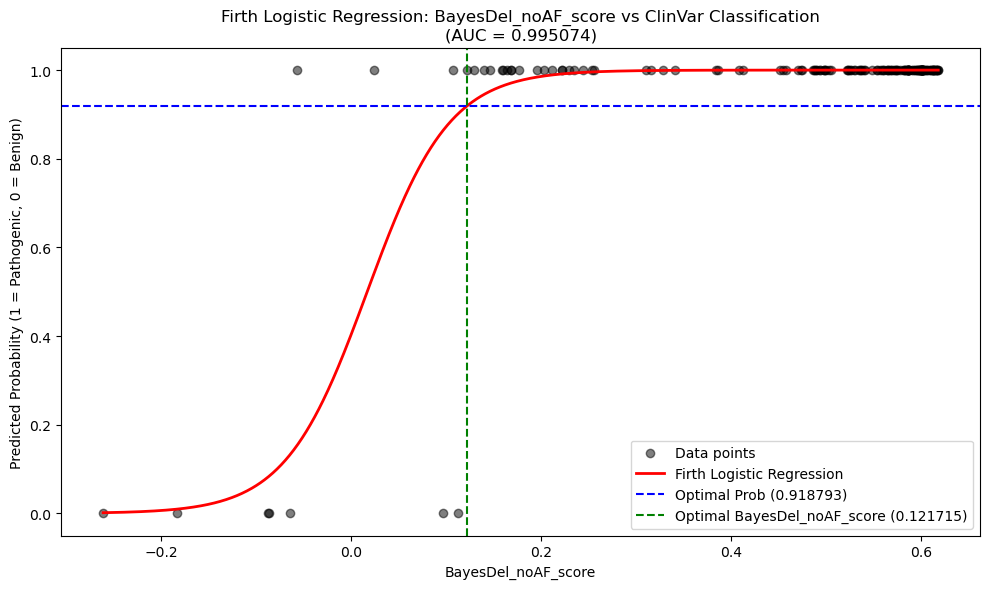

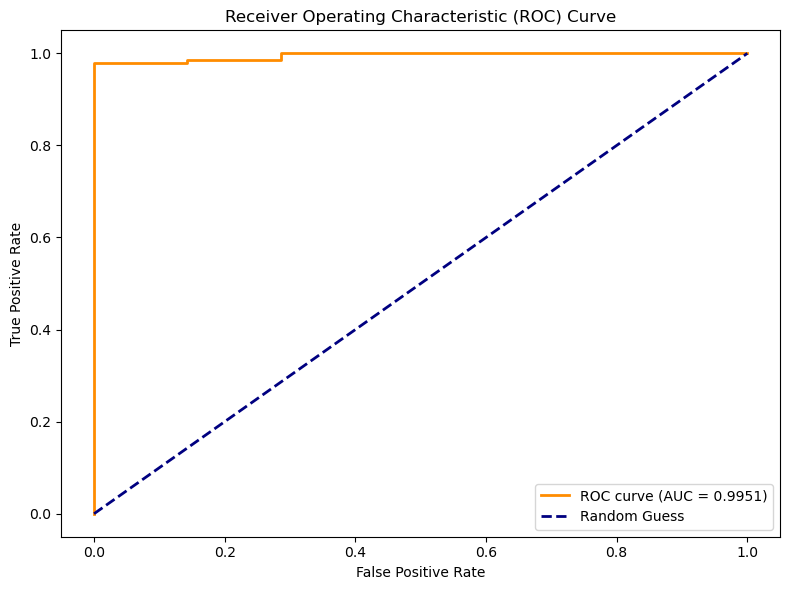

(array([10.40262556,  4.49592   ]), 0.9187925414701056, 0.12171520720720719)

In [26]:
firth_logistic_regression("/Users/keyuchen/FH_mutations_class_loose_label.csv", "BayesDel_noAF_score")

      fun: 6.797210958643887
 hess_inv: array([[10.27283685,  4.37091946],
       [ 4.37091946,  2.00389061]])
      jac: array([ 5.36441803e-07, -7.15255737e-07])
  message: 'Optimization terminated successfully.'
     nfev: 60
      nit: 19
     njev: 20
   status: 0
  success: True
        x: array([9.7024346 , 4.10252264])
AUC: 0.9955
Optimal probability cutoff: 0.8797
Sensitivity (TPR): 0.9843
Specificity (TNR): 1.0000
Accuracy: 0.9851
Optimal BayesDel_noAF_score cutoff: 0.121715


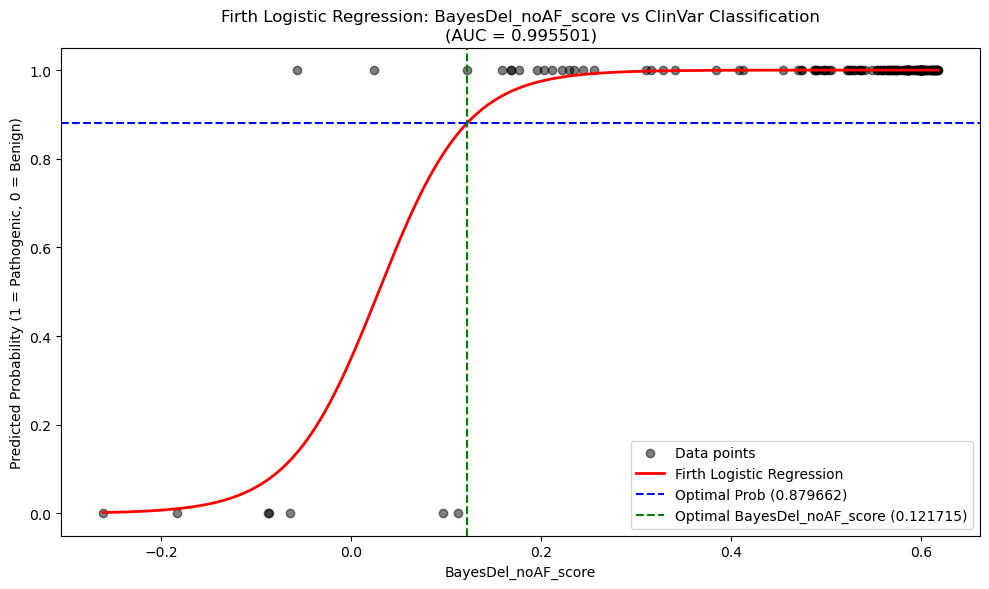

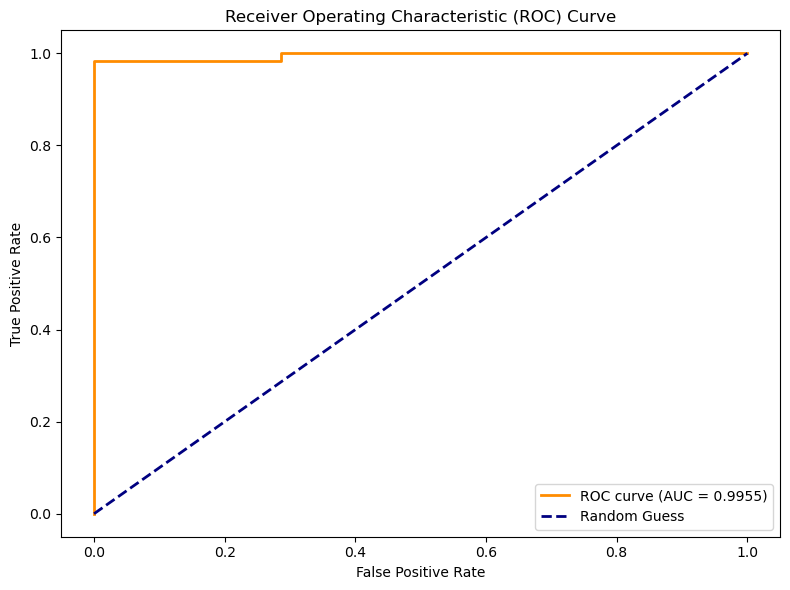

(array([9.7024346 , 4.10252264]), 0.8796623799663237, 0.12171520720720719)

In [315]:
firth_logistic_regression("/Users/keyuchen/FH_mutations_class_strict_label.csv", "BayesDel_noAF_score")

      fun: 5.505001837729753
 hess_inv: array([[8.76733217, 3.60320772],
       [3.60320772, 1.76478069]])
      jac: array([-1.19209290e-06, -5.96046448e-08])
  message: 'Optimization terminated successfully.'
     nfev: 60
      nit: 19
     njev: 20
   status: 0
  success: True
        x: array([8.92208523, 3.81911324])
AUC: 0.9961
Optimal probability cutoff: 0.9782
Sensitivity (TPR): 0.9793
Specificity (TNR): 1.0000
Accuracy: 0.9803
Optimal BayesDel_addAF_score cutoff: 0.250115


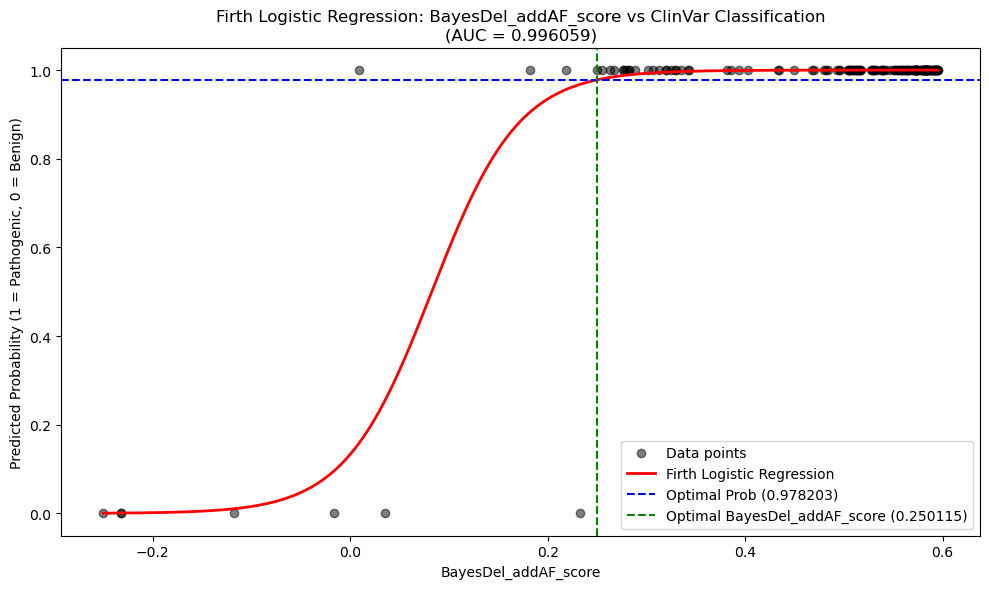

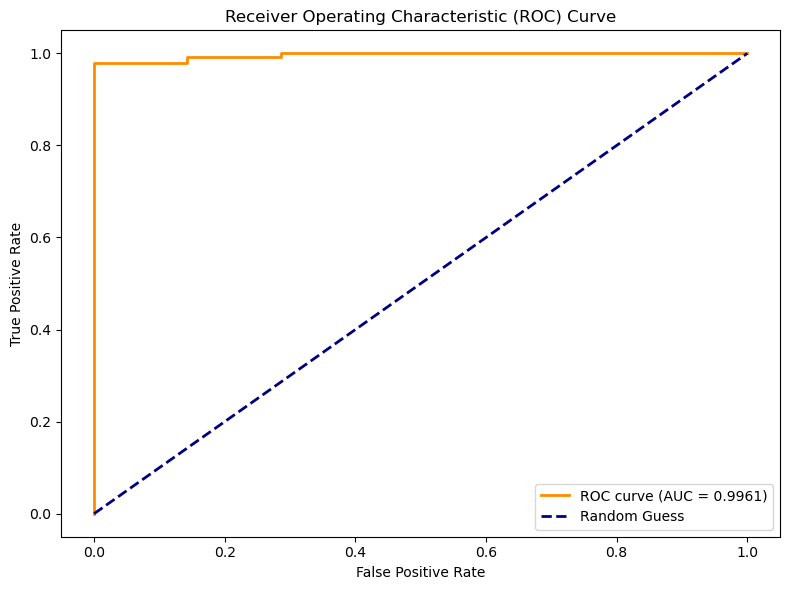

(array([8.92208523, 3.81911324]), 0.9782028560163556, 0.25011512612612613)

In [316]:
firth_logistic_regression("/Users/keyuchen/FH_mutations_class_loose_label.csv", "BayesDel_addAF_score")

      fun: 5.117861574031047
 hess_inv: array([[8.77871066, 3.552141  ],
       [3.552141  , 1.73644216]])
      jac: array([-6.55651093e-07, -1.07288361e-06])
  message: 'Optimization terminated successfully.'
     nfev: 60
      nit: 19
     njev: 20
   status: 0
  success: True
        x: array([8.56746339, 3.73460235])
AUC: 0.9966
Optimal probability cutoff: 0.9695
Sensitivity (TPR): 0.9843
Specificity (TNR): 1.0000
Accuracy: 0.9851
Optimal BayesDel_addAF_score cutoff: 0.250115


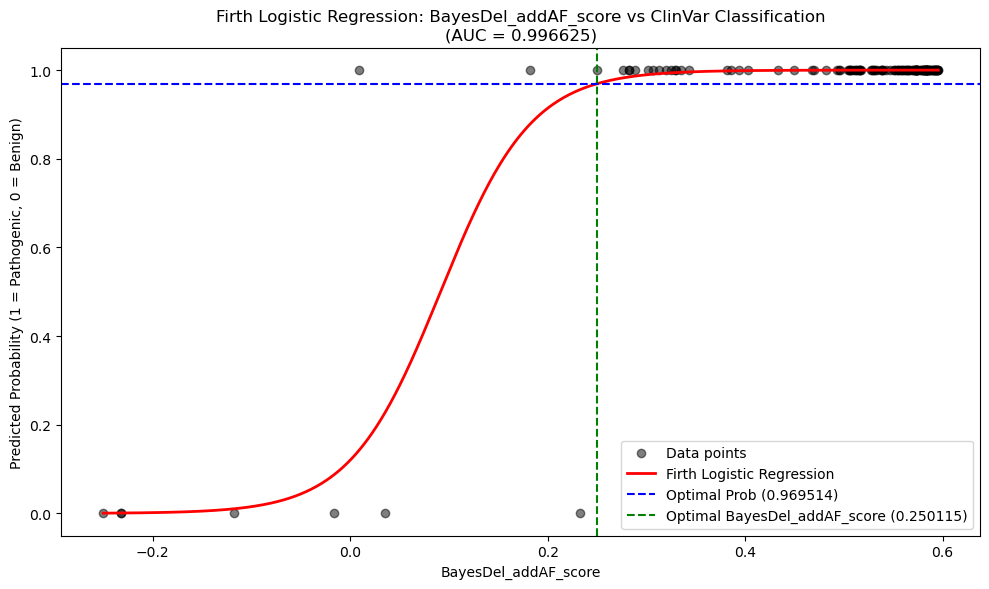

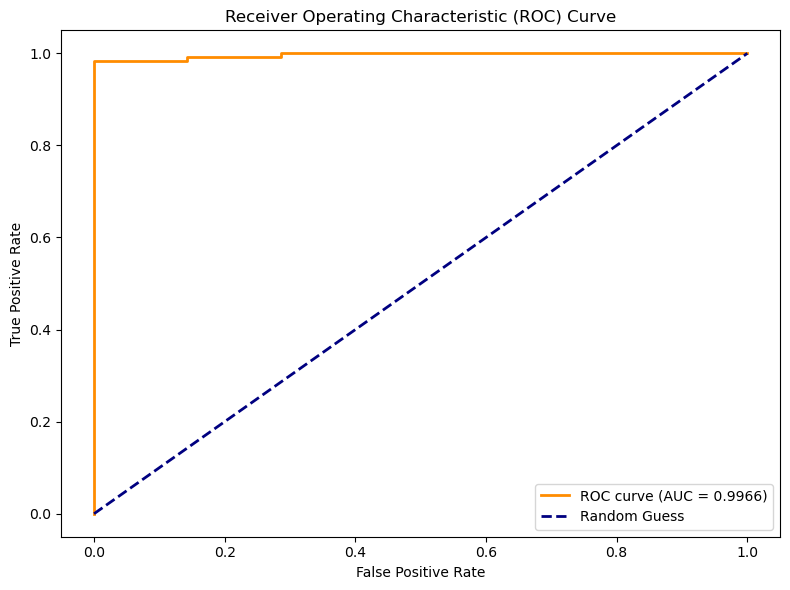

(array([8.56746339, 3.73460235]), 0.9695143975691806, 0.25011512612612613)

In [317]:
firth_logistic_regression("/Users/keyuchen/FH_mutations_class_strict_label.csv", "BayesDel_addAF_score")

##### Summary of results and key findings

Summary of the cutoff values:


| Dataset                    | AUC    | Optimal Prob Cutoff | Score Cutoff | Sensitivity (TPR) | Specificity (TNR) | Accuracy  |
|----------------------------|--------|----------------------|--------------|-------------------|-------------------|-----------|
| REVEL loose                | 0.9941 | 0.9471               | 0.648828     | 0.9793            | 1.0000            | 0.9803    |
| REVEL strict               | 0.9978 | 0.9974               | 0.648828     | 0.9921            | 1.0000            | 0.9925    |
| BayesDel_noAF loose        | 0.9951 | 0.9188               | 0.121715     | 0.9793            | 1.0000            | 0.9803    |
| BayesDel_noAF strict       | 0.9955 | 0.8797               | 0.121715     | 0.9843            | 1.0000            | 0.9851    |
| BayesDel_addAF loose       | 0.9961 | 0.9782               | 0.250115     | 0.9793            | 1.0000            | 0.9803    |
| BayesDel_addAF strict      | 0.9966 | 0.9695               | 0.250115     | 0.9843            | 1.0000            | 0.9851    |

From the table above, we can conclude that:
- Loose / strict classification don't affect gene pathogenicity classification, use either one is OK.
- Generally, strict classification has higher statistical value (closer to 1), which makes sense.
- It looks like REVEL performs the best. Proved by Linhua's work on the correlation between REVEl and BayesDel, it's unnecessary to run both of the data. Therefore, we chose to use REVEL.

##### Threshold uncertainty: Bootstrapping

##### Work to be done

To assess the robustness of the gene-level thresholds we derived for benign and deleterious evidence, we estimated 90% confidence intervals (CI) from 10,000 bootstrapping replicates stratified by classification status [1]

Reference:

[1] [Y. Tian et al., “REVEL and BayesDel outperform other in silico meta-predictors for clinical variant classification,” Scientific Reports, vol. 9, no. 1, Sep. 2019, doi: 10.1038/s41598-019-49224-8.](https://www.nature.com/articles/s41598-019-49224-8)

## Part 4: Suggested work (Above)

### Regression model

In our notebook, we used firth logistic regression, suitable for rare events and event with small size. We notice that, we are highly confident to predict the pathogenic as we have more data for it.

One suggested improvement is, while developing the gene specific meta-predictor thresholds, 'Regularization' can be used, including Lasso regression (L1) and Ridge regression (L2). As technique used in machine learning, this required larger data set that split the data into training and validation data. This is good to provide model overfit, with multiple variables, Lasso regression can even eliminate the irrelevant variable term.

### ClinVar classification


In our notebook, 'likely benign', 'benign/likely benign' and 'benign' are both classified as benign, both assigned with value '0'. However, the true is, in ClinVar classification, 'likely benign' has 90% probability to be benign. Therefore, it's useful to incorporate this information and develop new model.

## Part 5: Mechanistic cutoff

After group discussion in 04/03/2025, Cem and I have clear workflow for the last 4 weeks.

- Keyu: Incorporate the mechanistic model and meta-predictor to develop an overall model with cutoff value
- Cem: Investigate meta-predictor / mechanistic model in predicting pathogenicity in each residue / protein area, as for some region / residue, meta-predictor / mechanistic model might perform better than the other.
- Cem's research can feed back to my research, by eliminating controversial region / residue, and see whether the performance of the overall model improve.

Thanks to Cem, who provide the code for ROC analysis, where in this notebook I will run through the process with new BayesDel and REVEL cutoff values.

Outline of the workflows:
- Label the dataset with pathogenic / begin with new REVEL cutoff value
- Run the ROC for each mechanistic model to find the optimal cutoff values
- Label the data with pathogenic / begin with mechanistic model cutoff values
- (may be difference, explain the difference)

#### Data preparing

For detail information, check Cem's Python notebook.

In [712]:
import pandas as pd
import scipy.stats
import re

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

from sklearn.metrics import confusion_matrix
from IPython.display import display


In [713]:
mech_model = pd.read_csv("/Users/keyuchen/FH_mechanistic.csv")
score_model = pd.read_csv("/Users/keyuchen/FH_mutations_6.csv")
mech_model

,Unnamed: 0,Residue,AAfrom,AAto,rhapsodyscore,rhapsodyclass,polyphenscore,polyphenclass,Foldx_energy,Rosetta_energy,Mutation,average_energy,RSA,Mindist_bindingsiteA,Mindist_hinge
0,0,49,S,A,0.086,neutral,0.000,neutral,0.061363,3.265,S49A,1.663182,0.992308,23.461148,33.713100
1,1,49,S,C,0.535,neutral,0.860,deleterious,0.067352,7.990,S49C,4.028676,0.992308,23.461148,33.713100
2,2,49,S,D,0.052,neutral,0.000,neutral,-0.103203,1.891,S49D,0.893899,0.992308,23.461148,33.713100
3,3,49,S,E,0.049,neutral,0.000,neutral,-0.086741,0.983,S49E,0.448129,0.992308,23.461148,33.713100
4,4,49,S,F,0.529,neutral,0.620,deleterious,0.182080,4.837,S49F,2.509540,0.992308,23.461148,33.713100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8773,8773,510,K,S,0.705,prob.delet.,0.382,neutral,0.571362,1.871,K510S,1.221181,0.717073,14.891393,15.359364
8774,8774,510,K,T,0.701,prob.delet.,0.495,neutral,0.862076,1.330,K510T,1.096038,0.717073,14.891393,15.359364
8775,8775,510,K,V,0.657,prob.neutral,0.143,neutral,1.125190,-0.576,K510V,0.274595,0.717073,14.891393,15.359364
8776,8776,510,K,W,0.746,deleterious,0.993,deleterious,0.686269,-0.158,K510W,0.264134,0.717073,14.891393,15.359364


In [714]:
score_model.rename(columns={
    'aapos': 'Residue',
    'aaalt': 'AAto',
    'aaref': 'AAfrom'
}, inplace=True)

score_model = score_model[["AAto","AAfrom","Residue","BayesDel_noAF_score"]]
score_model.head()

,AAto,AAfrom,Residue,BayesDel_noAF_score
0,N,K,510,0.052162
1,M,K,510,0.226338
2,R,K,510,0.090205
3,T,K,510,0.257605
4,E,K,510,0.199121


In [715]:
FH_merge = score_model.merge(mech_model, on = ["Residue", "AAfrom", "AAto"])
FH_merge.head()

,AAto,AAfrom,Residue,BayesDel_noAF_score,Unnamed: 0,rhapsodyscore,rhapsodyclass,polyphenscore,polyphenclass,Foldx_energy,Rosetta_energy,Mutation,average_energy,RSA,Mindist_bindingsiteA,Mindist_hinge
0,N,K,510,0.052162,8769,0.712,deleterious,0.765,deleterious,0.376292,0.300,K510N,0.338146,0.717073,14.891393,15.359364
1,M,K,510,0.226338,8768,0.629,neutral,0.749,deleterious,0.559204,-0.019,K510M,0.270102,0.717073,14.891393,15.359364
2,R,K,510,0.090205,8772,0.639,prob.neutral,0.079,neutral,-0.292345,-0.738,K510R,-0.515173,0.717073,14.891393,15.359364
3,T,K,510,0.257605,8774,0.701,prob.delet.,0.495,neutral,0.862076,1.330,K510T,1.096038,0.717073,14.891393,15.359364
4,E,K,510,0.199121,8762,0.452,neutral,0.009,neutral,0.730662,2.188,K510E,1.459331,0.717073,14.891393,15.359364


In [716]:
# Convert all columns to string format
FH_merge = FH_merge.astype(str)

# Convert REVEL_score back to numeric for comparison
FH_merge['BayesDel_noAF_score'] = pd.to_numeric(FH_merge['BayesDel_noAF_score'], errors='coerce')

# Classify REVEL_score: 0 if <= 0.6, otherwise 1
FH_merge['score_class'] = FH_merge['BayesDel_noAF_score'].apply(lambda x: 1 if x >= 0.121715  else 0)


FH_merge = FH_merge.drop(columns=["Unnamed: 0", "Mutation"])
FH_merge.head()

,AAto,AAfrom,Residue,BayesDel_noAF_score,rhapsodyscore,rhapsodyclass,polyphenscore,polyphenclass,Foldx_energy,Rosetta_energy,average_energy,RSA,Mindist_bindingsiteA,Mindist_hinge,score_class
0,N,K,510,0.052162,0.712,deleterious,0.765,deleterious,0.376292,0.3,0.338146,0.717073171,14.89139297,15.35936366,0
1,M,K,510,0.226338,0.629,neutral,0.749,deleterious,0.559204,-0.019,0.270102,0.717073171,14.89139297,15.35936366,1
2,R,K,510,0.090205,0.639,prob.neutral,0.079,neutral,-0.292345,-0.738,-0.5151725,0.717073171,14.89139297,15.35936366,0
3,T,K,510,0.257605,0.701,prob.delet.,0.495,neutral,0.862076,1.33,1.096038,0.717073171,14.89139297,15.35936366,1
4,E,K,510,0.199121,0.452,neutral,0.009,neutral,0.730662,2.188,1.459331,0.717073171,14.89139297,15.35936366,1


In [717]:
FH_merge.to_csv("/Users/keyuchen/FH_merge.csv", index=False)

Before we move to the next part, the data above can be classified as
- BayesDel_addAF_score / rhapsodyscore / polyphenscore: prediction score -> Machine Learning-Based Methods
- Foldx_energy / Rosetta_energy / average_energy: Protein Stability & Energy Impact -> Empirical/Physics-Based Methods
- RSA (Relative Solvent Accessibility) / Mindist_bindingsiteA / Mindist_hinge: Structural & Binding Properties -> Structural Calculations

Why do we choose FoldX and Rosetta to predict pathogenetic from energy perspective? [1]
- FoldX outperform other energy predictors, and computationally efficient.
- Rosetta 
- good agreement between the FoldX and Rosetta methods (Spearman r = 0.67, p < 0.0001, Pearson r = 0.56) for all mutational energies.

Why do we use the Mindist_bindingsiteA / Mindist_hinge?
- suggested by the paper [2]


Reference:

[1] H. A. Al-Madhagi, “Computational identification of most deleterious missense mutations in human PD-1 gene,” The Scientific World JOURNAL, vol. 2023, pp. 1–11, Aug. 2023, doi: 10.1155/2023/4360203.

[2] D. Shorthouse, H. Lister, G. S. Freeman, and B. A. Hall, “Understanding large scale sequencing datasets through changes to protein folding,” Briefings in Functional Genomics, Mar. 2024, doi: 10.1093/bfgp/elae007.

#### ROC analysis

In the data, we have scores from 6 mechanistic models, they are: 


| **Feature**               | **Description** |
|---------------------------|----------------|
| **Foldx_energy**          | A structural stability score predicting the effect of mutation on protein stability. |
| **Rosetta_energy**        | Another energy-based metric from the Rosetta modeling suite for protein stability prediction. |
| **average_energy**        | The mean energy change caused by the mutation. |
| **RSA (Relative Solvent Accessibility)** | Measures how exposed the residue is in the protein structure. |
| **Mindist_bindingsiteA**  | The minimum distance of the mutation site to a binding site (A). |
| **Mindist_hinge**         | The minimum distance of the mutation site to a hinge region in the protein. |

This table is generated by Chat GPT, later I will do more research about the difference between different models. But now, it's useful to gain an general understanding about what each model do.

In [718]:
roc_y = FH_merge[["score_class"]]
roc_x = FH_merge[["Foldx_energy", "Rosetta_energy", "average_energy","Mindist_bindingsiteA","Mindist_hinge","RSA"]]
roc_x = roc_x.astype(float)
plotting_frame = pd.concat([roc_x, roc_y], axis =1)
true_values = plotting_frame["score_class"].to_list()

In [719]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(plotting_frame, true_values, column_name, threshold_range, title_suffix, comparator):
    """
    Plots an ROC curve for a given dataset.
    
    Parameters:
    plotting_frame : DataFrame
        The dataset containing the predictor variable.
    true_values : list or array
        The true binary labels.
    column_name : str
        The name of the column to use for threshold comparison.
    threshold_range : array-like, optional
        The range of threshold values to test.
    title_suffix : str, optional
        The suffix to be used in the plot title.
    comparator : str, optional
        The comparison operator to use ('>=' or '<=').
    """
    predlist = []
    roc_curvedata = []
    
    for i in threshold_range:
        if comparator == ">=":
            pred = [1 if item >= i else 0 for item in plotting_frame[column_name]]
        elif comparator == "<=":
            pred = [1 if item <= i else 0 for item in plotting_frame[column_name]]
        else:
            raise ValueError("Invalid comparator. Use '>=' or '<='")
        
        predlist.append(pred)
        fpr, tpr, _ = roc_curve(true_values, pred)
        roc_auc = auc(fpr, tpr)
        curvelist = [i, fpr[1], tpr[1], roc_auc]
        roc_curvedata.append(curvelist)
    
    roc_dataframe = pd.DataFrame(roc_curvedata, columns=["threshold", "fpr", "tpr", "auc"])
    
    fig, ax = plt.subplots()
    plt.plot(roc_dataframe["fpr"], roc_dataframe["tpr"], c="r")
    plt.plot(np.arange(0, 1.01, 0.01), np.arange(0, 1.01, 0.01), linestyle="dashed")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC analysis, {title_suffix}")
    plt.grid()
    plt.show()

    with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
        display(roc_dataframe.sort_values(by="auc", ascending=False).head(5))

In [720]:
import pandas as pd

def evaluate_classification(data, cutoff, energy_column, comparator):
    """
    Evaluate classification performance based on a given cutoff value.
    
    Parameters:
    data : DataFrame
        The dataset containing the predictor and classification labels.
    cutoff : float
        The threshold value used for classification.
    energy_column : str
        The column name used for threshold comparison.
    comparator : str, optional
        The comparison operator to use ('<=', '>=', or '=='). Default is '<='.
    """
    ds_calc = data[data["score_class"] == 1]  # Deleterious cases
    bs_calc = data[data["score_class"] == 0]  # Benign cases
    
    # Apply the cutoff threshold for classification
    if comparator == "<=":
        ds_calc_nofold = ds_calc[ds_calc[energy_column].astype(float) <= cutoff]
        bs_calc_nofold = bs_calc[bs_calc[energy_column].astype(float) <= cutoff]
    elif comparator == ">=":
        ds_calc_nofold = ds_calc[ds_calc[energy_column].astype(float) >= cutoff]
        bs_calc_nofold = bs_calc[bs_calc[energy_column].astype(float) >= cutoff]
    
    # Calculate fractions of cases removed/retained
    fraction_deleterious_removed = len(ds_calc_nofold) / len(ds_calc)
    fraction_benign_retained = len(bs_calc_nofold) / len(bs_calc)
    
    print("### Classification Metrics ###")
    print(f"Fraction of deleterious cases incorrectly classified (removed): {fraction_deleterious_removed:.3f}")
    print(f"Fraction of benign cases correctly classified (retained): {fraction_benign_retained:.3f}\n")
    
    # Compute Confusion Matrix values
    TN = len(bs_calc_nofold)  # True Negatives: benign cases correctly classified
    FP = len(ds_calc_nofold)  # False Positives: deleterious cases incorrectly classified
    TP = len(ds_calc) - FP  # True Positives: deleterious cases correctly classified
    FN = len(bs_calc) - TN  # False Negatives: benign cases incorrectly classified
    
    # Compute key performance metrics
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # Avoid division by zero
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # Avoid division by zero
    
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Sensitivity (Recall): {sensitivity:.3f}")
    print(f"Specificity: {specificity:.3f}\n")
    
    # Detailed classification results
    print(f"False Positives (deleterious misclassified as benign): {FP}")
    print(f"True Positives (deleterious correctly classified): {TP}")
    print(f"Percentage of deleterious cases correctly classified: {TP * 100 / (TP + FP):.2f}%\n")
    
    print(f"False Negatives (benign misclassified as deleterious): {FN}")
    print(f"True Negatives (benign correctly classified): {TN}")
    print(f"Percentage of benign cases correctly classified: {TN * 100 / (TN + FN):.2f}%")

##### FoldX

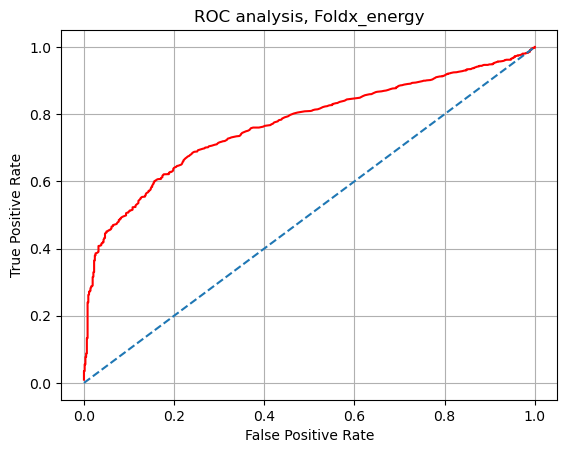

,threshold,fpr,tpr,auc
647,1.47,0.156200,0.600465,0.722133
609,1.09,0.241546,0.685581,0.722018
637,1.37,0.177134,0.620930,0.721898
610,1.10,0.239936,0.683721,0.721893
614,1.14,0.230274,0.673953,0.721840


In [721]:
plot_roc_curve(plotting_frame, true_values, "Foldx_energy", np.arange(-5,20,0.01), "Foldx_energy", ">=")

In [722]:
data = FH_merge
evaluate_classification(data, 1.47, "Foldx_energy", "<=")

### Classification Metrics ###
Fraction of deleterious cases incorrectly classified (removed): 0.400
Fraction of benign cases correctly classified (retained): 0.844

Accuracy: 0.655
Sensitivity (Recall): 0.930
Specificity: 0.379

False Positives (deleterious misclassified as benign): 859
True Positives (deleterious correctly classified): 1291
Percentage of deleterious cases correctly classified: 60.05%

False Negatives (benign misclassified as deleterious): 97
True Negatives (benign correctly classified): 524
Percentage of benign cases correctly classified: 84.38%


##### Rosetta

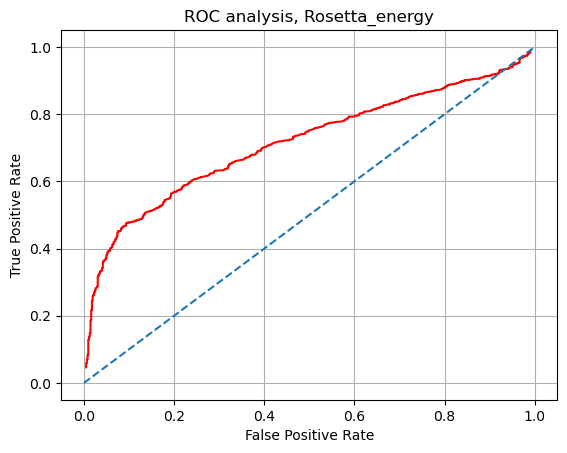

,threshold,fpr,tpr,auc
977,4.77,0.093398,0.474884,0.690743
976,4.76,0.093398,0.474884,0.690743
974,4.74,0.096618,0.477209,0.690295
975,4.75,0.096618,0.476279,0.689830
984,4.84,0.086957,0.466512,0.689778


In [723]:
plot_roc_curve(plotting_frame, true_values, "Rosetta_energy", np.arange(-5,20, 0.01), "Rosetta_energy", ">=")

In [724]:
data = FH_merge
evaluate_classification(data, 4.77, "Rosetta_energy", "<=")

### Classification Metrics ###
Fraction of deleterious cases incorrectly classified (removed): 0.525
Fraction of benign cases correctly classified (retained): 0.907

Accuracy: 0.572
Sensitivity (Recall): 0.946
Specificity: 0.333

False Positives (deleterious misclassified as benign): 1129
True Positives (deleterious correctly classified): 1021
Percentage of deleterious cases correctly classified: 47.49%

False Negatives (benign misclassified as deleterious): 58
True Negatives (benign correctly classified): 563
Percentage of benign cases correctly classified: 90.66%


##### Average energy

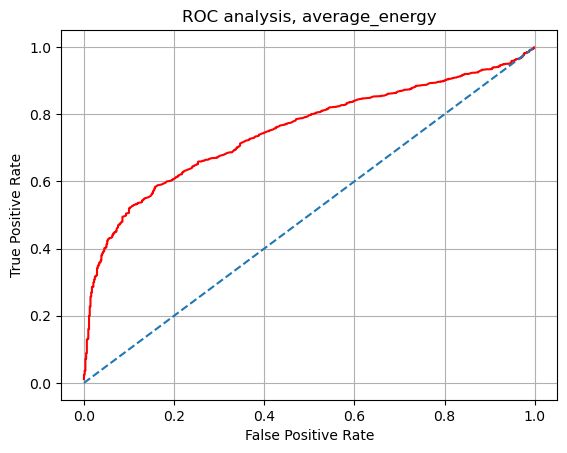

,threshold,fpr,tpr,auc
742,2.42,0.157810,0.584186,0.713188
743,2.43,0.157810,0.583256,0.712723
739,2.39,0.162641,0.587907,0.712633
741,2.41,0.159420,0.584651,0.712615
740,2.40,0.161031,0.585116,0.712043


In [725]:
plot_roc_curve(plotting_frame, true_values, "average_energy", np.arange(-5,20, 0.01), "average_energy", ">=")

In [726]:
data = FH_merge

evaluate_classification(data, 2.42, "average_energy", "<=")

### Classification Metrics ###
Fraction of deleterious cases incorrectly classified (removed): 0.416
Fraction of benign cases correctly classified (retained): 0.842

Accuracy: 0.642
Sensitivity (Recall): 0.928
Specificity: 0.369

False Positives (deleterious misclassified as benign): 894
True Positives (deleterious correctly classified): 1256
Percentage of deleterious cases correctly classified: 58.42%

False Negatives (benign misclassified as deleterious): 98
True Negatives (benign correctly classified): 523
Percentage of benign cases correctly classified: 84.22%


##### Minimum distance to binding site A

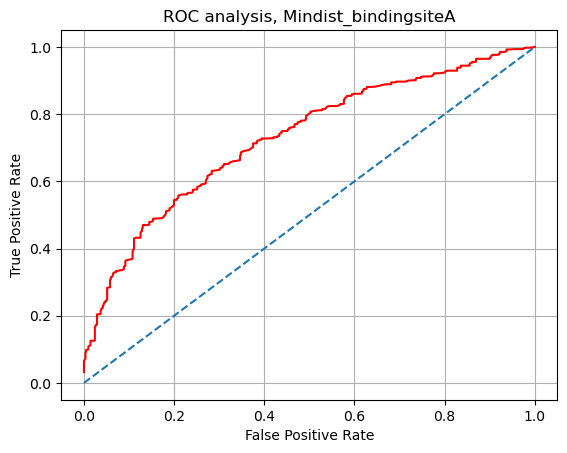

,threshold,fpr,tpr,auc
1352,13.52,0.20934,0.557209,0.673935
1356,13.56,0.20934,0.557209,0.673935
1351,13.51,0.20934,0.557209,0.673935
1350,13.50,0.20934,0.557209,0.673935
1349,13.49,0.20934,0.557209,0.673935


In [727]:
plot_roc_curve(plotting_frame, true_values, "Mindist_bindingsiteA", np.arange(0,40, 0.01), "Mindist_bindingsiteA", "<=")

In [728]:
data = FH_merge

evaluate_classification(data, 13.52, "Mindist_bindingsiteA", ">=")

### Classification Metrics ###
Fraction of deleterious cases incorrectly classified (removed): 0.443
Fraction of benign cases correctly classified (retained): 0.791

Accuracy: 0.610
Sensitivity (Recall): 0.902
Specificity: 0.340

False Positives (deleterious misclassified as benign): 952
True Positives (deleterious correctly classified): 1198
Percentage of deleterious cases correctly classified: 55.72%

False Negatives (benign misclassified as deleterious): 130
True Negatives (benign correctly classified): 491
Percentage of benign cases correctly classified: 79.07%


##### Minimum distance to hinge site

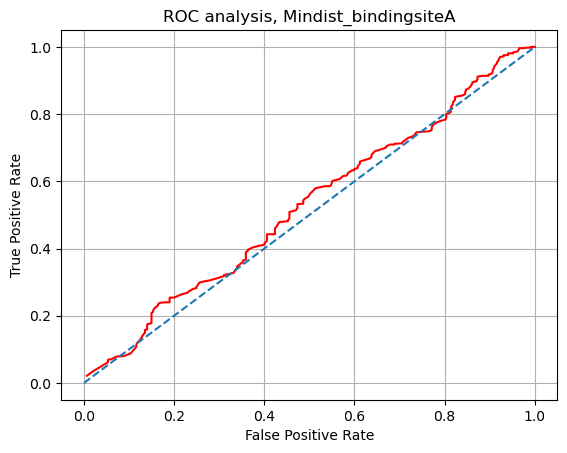

,threshold,fpr,tpr,auc
90,9.0,0.167472,0.238140,0.535334
89,8.9,0.164251,0.233488,0.534619
88,8.8,0.164251,0.230698,0.533223
162,16.2,0.513688,0.579535,0.532924
163,16.3,0.513688,0.579535,0.532924


In [729]:
plot_roc_curve(plotting_frame, true_values, "Mindist_hinge", np.arange(0,100, 0.1), "Mindist_bindingsiteA", "<=")

In [730]:
data = FH_merge

evaluate_classification(data, 9.0, "Mindist_hinge", ">=")

### Classification Metrics ###
Fraction of deleterious cases incorrectly classified (removed): 0.762
Fraction of benign cases correctly classified (retained): 0.833

Accuracy: 0.371
Sensitivity (Recall): 0.831
Specificity: 0.240

False Positives (deleterious misclassified as benign): 1638
True Positives (deleterious correctly classified): 512
Percentage of deleterious cases correctly classified: 23.81%

False Negatives (benign misclassified as deleterious): 104
True Negatives (benign correctly classified): 517
Percentage of benign cases correctly classified: 83.25%


##### RSA

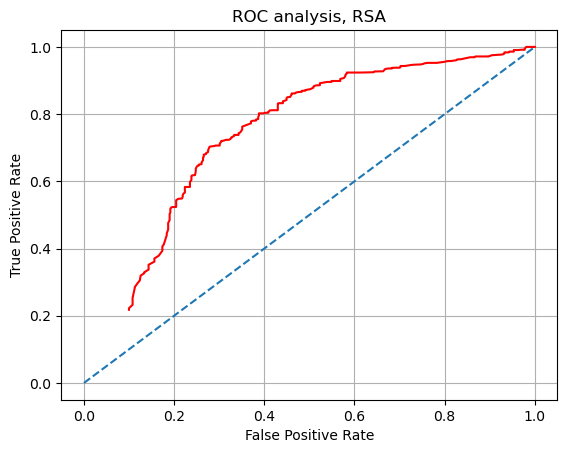

,threshold,fpr,tpr,auc
150,0.150,0.278583,0.702791,0.712104
154,0.154,0.278583,0.702791,0.712104
151,0.151,0.278583,0.702791,0.712104
149,0.149,0.278583,0.702791,0.712104
148,0.148,0.278583,0.702791,0.712104


In [731]:
plot_roc_curve(plotting_frame, true_values, "RSA", np.arange(0,1, 0.001), "RSA", "<=")

In [732]:
evaluate_classification(data, 0.150, "RSA", ">=")

### Classification Metrics ###
Fraction of deleterious cases incorrectly classified (removed): 0.297
Fraction of benign cases correctly classified (retained): 0.721

Accuracy: 0.707
Sensitivity (Recall): 0.897
Specificity: 0.412

False Positives (deleterious misclassified as benign): 639
True Positives (deleterious correctly classified): 1511
Percentage of deleterious cases correctly classified: 70.28%

False Negatives (benign misclassified as deleterious): 173
True Negatives (benign correctly classified): 448
Percentage of benign cases correctly classified: 72.14%


##### Conclusion and idea

As prove by Linhua's work, REVEL, BayesDel_addAF and BayesDel_noAF are highly correlated, therefore any one of the data with the universal threshold and new threshold is sufficient. 

Performance comments:
- Energy (Foldx_energy, Rosetta_energy, average_energy) perform quite well with approximately 70% accuracy
- Structural prediction: Mindist_bindingsiteA, RSA perform quite well with approximately 70% accuracy, while for Mindist_hinge there is no difference with random guess.
- The ROC result, not surprisingly, is consistence with previous work. [1] Energy the best, binding site second, hinge the worst.

Reference:

[1] D. Shorthouse, M. W. J. Hall, and B. A. Hall, “Computational Saturation screen reveals the landscape of mutations in human fumarate hydratase,” Journal of Chemical Information and Modeling, vol. 61, no. 4, pp. 1970–1980, Apr. 2021, doi: 10.1021/acs.jcim.1c00063.


#### Model classification

In here, we use the cutoff values found (by comparing with BayesDel_addAF_score classification, universal threshold. This is flexible to change) in last part ROC analysis.

Cutoff values:
- Foldx_energy: 1.47
- Rosetta_energy: 4.77
- average_energy: 2.42
- Mindist_bindingsiteA: 13.52
- RSA: 0.150

In [736]:
FH_merge_class = pd.read_csv("/Users/keyuchen/FH_merge.csv")

cutoffs = {
    "Foldx_energy": 1.47,
    "Rosetta_energy": 4.77,
    "average_energy": 2.42,
    "Mindist_bindingsiteA": 13.52,
    "RSA": 0.150
}

# Apply classification for each cutoff individually
# the astype(int) converts the true/false to 1/0
FH_merge_class["Foldx_Class"] = (FH_merge_class["Foldx_energy"] >= cutoffs["Foldx_energy"]).astype(int)
FH_merge_class["Rosetta_Class"] = (FH_merge_class["Rosetta_energy"] >= cutoffs["Rosetta_energy"]).astype(int)
FH_merge_class["Average_Energy_Class"] = (FH_merge_class["average_energy"] >= cutoffs["average_energy"]).astype(int)
FH_merge_class["Mindist_Binding_Class"] = (FH_merge_class["Mindist_bindingsiteA"] <= cutoffs["Mindist_bindingsiteA"]).astype(int)
FH_merge_class["RSA_Class"] = (FH_merge_class["RSA"] <= cutoffs["RSA"]).astype(int)

FH_merge_class.head()

,AAto,AAfrom,Residue,BayesDel_noAF_score,rhapsodyscore,rhapsodyclass,polyphenscore,polyphenclass,Foldx_energy,Rosetta_energy,average_energy,RSA,Mindist_bindingsiteA,Mindist_hinge,score_class,Foldx_Class,Rosetta_Class,Average_Energy_Class,Mindist_Binding_Class,RSA_Class
0,N,K,510,0.052162,0.712,deleterious,0.765,deleterious,0.376292,0.300,0.338146,0.717073,14.891393,15.359364,0,0,0,0,0,0
1,M,K,510,0.226338,0.629,neutral,0.749,deleterious,0.559204,-0.019,0.270102,0.717073,14.891393,15.359364,1,0,0,0,0,0
2,R,K,510,0.090205,0.639,prob.neutral,0.079,neutral,-0.292345,-0.738,-0.515173,0.717073,14.891393,15.359364,0,0,0,0,0,0
3,T,K,510,0.257605,0.701,prob.delet.,0.495,neutral,0.862076,1.330,1.096038,0.717073,14.891393,15.359364,1,0,0,0,0,0
4,E,K,510,0.199121,0.452,neutral,0.009,neutral,0.730662,2.188,1.459331,0.717073,14.891393,15.359364,1,0,0,0,0,0


In [737]:
FH_merge_class.to_csv("/Users/keyuchen/FH_merge_class.csv", index=False)

Below, I put the rows that have the same classification (i.e., 00000 / 11111 across all 5 classification) in the top of the data frame. 

In [738]:
import pandas as pd

# Load the dataset
file_path = "/Users/keyuchen/FH_merge_class.csv"  # Update this path as needed
FH_merge_class = pd.read_csv(file_path)

# Define classification columns
classification_cols = ["score_class", "Foldx_Class", "Rosetta_Class", "Average_Energy_Class", "Mindist_Binding_Class", "RSA_Class"]

# Identify rows where all classification values are the same (either all 0s or all 1s)
all_zeros = FH_merge_class[classification_cols].eq(0).all(axis=1)
all_ones = FH_merge_class[classification_cols].eq(1).all(axis=1)

# Extract those rows
matching_rows = FH_merge_class[all_zeros | all_ones]
other_rows = FH_merge_class[~(all_zeros | all_ones)]

# Concatenate the extracted rows on top of the remaining dataset
FH_merge_class_1 = pd.concat([matching_rows, other_rows], ignore_index=True)

# Display the updated DataFrame
import IPython.display as display
display.display(FH_merge_class_1)

FH_merge_class_1.to_csv("/Users/keyuchen/FH_merge_class_top.csv", index=False)

,AAto,AAfrom,Residue,BayesDel_noAF_score,rhapsodyscore,rhapsodyclass,polyphenscore,polyphenclass,Foldx_energy,Rosetta_energy,average_energy,RSA,Mindist_bindingsiteA,Mindist_hinge,score_class,Foldx_Class,Rosetta_Class,Average_Energy_Class,Mindist_Binding_Class,RSA_Class
0,N,K,510,0.052162,0.712,deleterious,0.765,deleterious,0.376292,0.300,0.338146,0.717073,14.891393,15.359364,0,0,0,0,0,0
1,R,K,510,0.090205,0.639,prob.neutral,0.079,neutral,-0.292345,-0.738,-0.515173,0.717073,14.891393,15.359364,0,0,0,0,0,0
2,Q,K,510,0.061771,0.456,neutral,0.002,neutral,0.467419,2.556,1.511710,0.717073,14.891393,15.359364,0,0,0,0,0,0
3,S,G,508,0.119142,0.585,neutral,0.992,deleterious,1.462110,2.108,1.785055,0.178571,13.571002,8.953523,0,0,0,0,0,0
4,M,L,507,0.056900,0.843,deleterious,0.995,deleterious,0.196299,-0.140,0.028150,0.213415,15.116476,6.032149,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2766,I,F,50,0.059548,0.171,neutral,0.001,neutral,2.260600,1.613,1.936800,0.538071,20.361040,31.838771,0,1,0,0,0,0
2767,V,F,50,0.151609,0.167,neutral,0.001,neutral,1.964840,0.900,1.432420,0.538071,20.361040,31.838771,1,1,0,0,0,0
2768,C,S,49,0.042089,0.535,neutral,0.860,deleterious,0.067352,7.990,4.028676,0.992308,23.461148,33.713100,0,0,1,1,0,0
2769,F,S,49,0.058733,0.529,neutral,0.620,deleterious,0.182080,4.837,2.509540,0.992308,23.461148,33.713100,0,0,1,1,0,0


Across the data, 797/2771 = 28.76% of the data has correct classification across all 5 methods

When I start thinking how to design a model that incorporate all five methods (including the hinge side as well), I revisited the paper [1] which also study the FH mutation. The classification workflow suggested by the paper is
1. near binding site (LOF - binding)
2. near hinge site (LOF - hinge)
3. check average energy
   1. if RSA < 0.2 then LOF - destabilizing
   2. if RSA > 0.2 then begin

Well, in our research, apparently we can't use the binding site data first, as the model accuracy is extremely poor, nothing difference with random guess. Therefore, new workflow is required

Reference:

[1] D. Shorthouse, M. W. J. Hall, and B. A. Hall, “Computational Saturation screen reveals the landscape of mutations in human fumarate hydratase,” Journal of Chemical Information and Modeling, vol. 61, no. 4, pp. 1970–1980, Apr. 2021, doi: 10.1021/acs.jcim.1c00063.

In [739]:
# Pearson correlation (linear relationship)
pearson_corr = FH_merge_class_1["Mindist_bindingsiteA"].corr(FH_merge_class_1["Mindist_hinge"], method="pearson")

# Spearman correlation (monotonic relationship)
spearman_corr = FH_merge_class_1["Mindist_bindingsiteA"].corr(FH_merge_class_1["Mindist_hinge"], method="spearman")

print(f"Pearson Correlation: {pearson_corr:.3f}")
print(f"Spearman Correlation: {spearman_corr:.3f}")


Pearson Correlation: -0.074
Spearman Correlation: -0.086


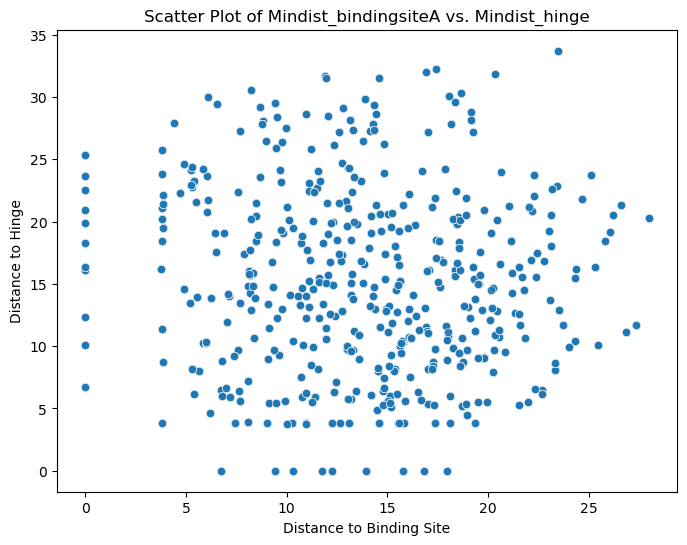

In [740]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=FH_merge_class_1["Mindist_bindingsiteA"], y=FH_merge_class_1["Mindist_hinge"], alpha=0.7)
plt.xlabel("Distance to Binding Site")
plt.ylabel("Distance to Hinge")
plt.title("Scatter Plot of Mindist_bindingsiteA vs. Mindist_hinge")
plt.show()

We perform both Pearson and Spearman corelation test. But Spearman test is more logical, as it's rank test with no assumed linear relationship. (Pearson test assume linear relationship, continuous and normally distributed variables)

Apparently, they have no correlation. An idea I have is to take the average of the two distance, as both the distance to binding site and to hinge site are the theoretical structural calculations.

##### Test 1: average distance

In [742]:
FH_merge_2 = pd.read_csv("/Users/keyuchen/FH_merge.csv")

# Compute the average distance
FH_merge_2["Mindist_average"] = (FH_merge_2["Mindist_bindingsiteA"] + FH_merge_2["Mindist_hinge"]) / 2

# Display the first few rows to check
print(FH_merge_2[["Mindist_bindingsiteA", "Mindist_hinge", "Mindist_average"]].head())

# Save the updated dataset (optional)
FH_merge_2.to_csv("/Users/keyuchen/FH_merge_energy.csv", index=False)

   Mindist_bindingsiteA  Mindist_hinge  Mindist_average
0             14.891393      15.359364        15.125378
1             14.891393      15.359364        15.125378
2             14.891393      15.359364        15.125378
3             14.891393      15.359364        15.125378
4             14.891393      15.359364        15.125378


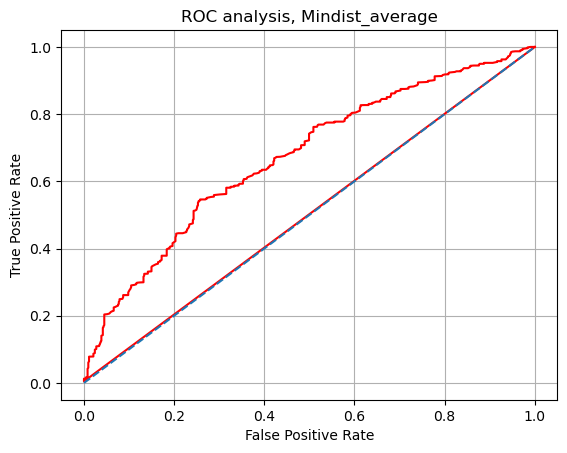

TypeError: 'module' object is not callable

In [743]:
roc_y = FH_merge_2[["score_class"]]
roc_x = FH_merge_2[["Mindist_average"]]
roc_x = roc_x.astype(float)
plotting_frame = pd.concat([roc_x, roc_y], axis =1)
true_values = plotting_frame["score_class"].to_list()

plot_roc_curve(plotting_frame, true_values, "Mindist_average", np.arange(2,30,0.01), "Mindist_average", "<=")

In [744]:
data = FH_merge_2

evaluate_classification(data, 14.23, "Mindist_average", ">=")

### Classification Metrics ###
Fraction of deleterious cases incorrectly classified (removed): 0.454
Fraction of benign cases correctly classified (retained): 0.742

Accuracy: 0.590
Sensitivity (Recall): 0.880
Specificity: 0.321

False Positives (deleterious misclassified as benign): 976
True Positives (deleterious correctly classified): 1174
Percentage of deleterious cases correctly classified: 54.60%

False Negatives (benign misclassified as deleterious): 160
True Negatives (benign correctly classified): 461
Percentage of benign cases correctly classified: 74.24%


I don't think taking average of the hinge and binding site distance is a good suggestion.

##### Test 2: Prioritize between parameters

Parameters importance rank: [1]
1. energy stability most predictive: 
   1. “ROC analysis (Figure 3b) identifies that the best cutoff for discriminating between small growth impairment and benign mutations is in the range of 2.5−3 kcal/mol (lowest distance to corner for cutoff 2.65 kcal/mol). We chose to apply a conservative 2.5 kcal/mol definition for LOF; as for patient screening, a larger number of false positives is favorable over false negatives, and this cutoff has been used previously in other studies of mutational energy.
   2. “We further confirm the validity of the method by calculating the number of mutants of each residue that are predicted to be disruptive through both the experimental data and the predicted ΔΔG—applying our cutoff of 2.5 kcal/mol, as shown in Figure 3c. We find a strong correlation between the predicted and experimental disruption rates (Pearson r = 0.68, p < 0.001), in particular both producing peaks at residue 25 and residue 100.”​
2. binding site distance: While 42 residues in the 462 amino acid protein structure (9%) are classified as being “binding site-associated”, we find that 11 of the 30 (36%) known LOF mutations are within these residues, showing a clear statistical enrichment toward binding site-associated mutations versus mutations occurring randomly across the structure (χ2 p value < 0.001).
3. hinge site distance: Similarly, 55 of the 462 (12%) amino acids in the protein structure are classified as “hinge- associated”, and we find 7 of the 30 (23%) within the FH mutation database fulfil this classification, showing a lesser but still large occurrence bias and enrichment (χ2 p value < 0.001).


Reference:

[1] D. Shorthouse, M. W. J. Hall, and B. A. Hall, “Computational Saturation screen reveals the landscape of mutations in human fumarate hydratase,” Journal of Chemical Information and Modeling, vol. 61, no. 4, pp. 1970–1980, Apr. 2021, doi: 10.1021/acs.jcim.1c00063.

New model workflow:
1. Run the classification with the average_energy threshold. Do the classification. -> previously paper state they have the highest priority (previous research suggestion)
2. Run the classification with the RSA threshold. Do the classification. -> previous ROC result shows it have the best statistic result, in terms of overall accuracy, and in predicting pathogenic and begin cases (both approximately 70%) (our statistical analysis suggestion)
3. If the classification in Step 1 and 2 are the same, stamp the final classification. If not, move to Step 4.
4. Now for the rest of the data, if one of the hinge / binding distance is <6 (recommended by other paper), then classified with 1 (pathogenic), otherwise 0 (begin). As you might aware, the case when stamp with 0 only when both hinge and binding site distance >6.
5. This step is added after I ran the first 4 step, when I found that many meta-predictor (in our case BayesDel) predicted pathogenic has been wrongly classified in the final class as they are far from binding / hinge side. Therefore, new step, Step 5, will revisit the case which both binding / hinge side classified as begin, we look back the energy and RSA data, if any of them classified as pathogenic, then update the final classification as pathogenic.

In [757]:
file_path = "/Users/keyuchen/FH_merge_class.csv"
df = pd.read_csv(file_path)

# Compare Average_Energy_Class and RSA_Class
df["final_class"] = df.apply(
    lambda row: row["Average_Energy_Class"] if row["Average_Energy_Class"] == row["RSA_Class"] else "NaN", axis=1)

# Save the updated dataset
output_path = "/Users/keyuchen/FH_merge_class_final.csv"
df.to_csv(output_path, index=False)

# Display the first few rows to verify the changes
print(df[["Average_Energy_Class", "RSA_Class", "final_class"]].head())

   Average_Energy_Class  RSA_Class final_class
0                     0          0           0
1                     0          0           0
2                     0          0           0
3                     0          0           0
4                     0          0           0


In the data, we found that:
- 1871/2771 = 67.52% of mutations consistence between RSA and average_energy prediction
- 32.48% of data need further classification

In [758]:
file_path = "/Users/keyuchen/FH_merge_class_final.csv" 
df = pd.read_csv(file_path)

df_cleaned = df.dropna(subset=["final_class"])
matching_count = (df_cleaned["final_class"] == df_cleaned["score_class"]).sum()
total_rows = len(df_cleaned)

print(f"Number of matching classifications: {matching_count}")
print(f"Total number of rows after removing NaN: {total_rows}")
print(f"Percentage match: {matching_count / total_rows:.2%}")
print(f"Cleaned dataset saved to: {output_path}")

Number of matching classifications: 1419
Total number of rows after removing NaN: 1871
Percentage match: 75.84%
Cleaned dataset saved to: /Users/keyuchen/FH_merge_class_final.csv


Excitingly, when comparing the initial classification with the score classification, the accuracy is 75.84%, higher than previous accuracy when using single predictor.

In [759]:
import pandas as pd

# Load the dataset
file_path = "/Users/keyuchen/FH_merge_class_final.csv"  # Update the file path
df = pd.read_csv(file_path)

# Compute classification based on thresholds
df.loc[df["final_class"].isna(), "binding_final_class"] = df["Mindist_bindingsiteA"].apply(lambda x: 1 if x <= 6 else 0)
df.loc[df["final_class"].isna(), "hinge_final_class"] = df["Mindist_hinge"].apply(lambda x: 1 if x <= 6 else 0)

# Update final_class based on new classifications
df.loc[df["final_class"].isna(), "final_class"] = df.apply(
    lambda row: 1 if (row["binding_final_class"] == 1 or row["hinge_final_class"] == 1) else 0,
    axis=1
)

# Additional condition: 
# If both hinge / binding distance classified as 0, check RSA and average_energy
df.loc[
    (df["binding_final_class"] == 0) & 
    (df["hinge_final_class"] == 0) &
    (df["Mindist_bindingsiteA"] > 6) & 
    (df["Mindist_hinge"] > 6) & 
    ((df["RSA_Class"] == 1) | (df["Average_Energy_Class"] == 1)), 
    "final_class"
] = 1

# Save the updated dataset
output_path = "/Users/keyuchen/FH_merge_class_final.csv"  # Update the file path
df.to_csv(output_path, index=False)

# Display a sample of the updated classifications
print(df[["final_class", "Mindist_bindingsiteA", "Mindist_hinge", "binding_final_class", "hinge_final_class", "RSA_Class", "Average_Energy_Class"]].head())


   final_class  Mindist_bindingsiteA  Mindist_hinge  binding_final_class  \
0          0.0             14.891393      15.359364                  NaN   
1          0.0             14.891393      15.359364                  NaN   
2          0.0             14.891393      15.359364                  NaN   
3          0.0             14.891393      15.359364                  NaN   
4          0.0             14.891393      15.359364                  NaN   

   hinge_final_class  RSA_Class  Average_Energy_Class  
0                NaN          0                     0  
1                NaN          0                     0  
2                NaN          0                     0  
3                NaN          0                     0  
4                NaN          0                     0  


In [760]:
file_path = "/Users/keyuchen/FH_merge_class_final.csv" 
df = pd.read_csv(file_path)

# Count consistent classifications (where final_class matches score_class)
consistent_count = (df["final_class"] == df["score_class"]).sum()

# Count inconsistent classifications (where final_class does not match score_class)
inconsistent_count = (df["final_class"] != df["score_class"]).sum()

# Get total number of rows
total_rows = len(df)

# Calculate percentage agreement
percentage_match = (consistent_count / total_rows) * 100

# Display results
comparison_results = {
    "Consistent Classifications": consistent_count,
    "Inconsistent Classifications": inconsistent_count,
    "Total Rows": total_rows,
    "Percentage Match": f"{percentage_match:.2f}%"
}

comparison_results

{'Consistent Classifications': 2160,
 'Inconsistent Classifications': 611,
 'Total Rows': 2771,
 'Percentage Match': '77.95%'}

##### Test 3: alternative to Test 2

New workflow:
- If any one of the RSA / average_energy stamp 1, then final_class will be 1.
- For the rest 0 cases, see the binding / hinge side distance. If one of then is 1, update final_class as 1. Otherwise keep 0.

In [761]:
import pandas as pd

# Load the dataset
file_path = "/Users/keyuchen/FH_merge_class_final.csv"
df = pd.read_csv(file_path)

# Compute binding and hinge classification based on threshold (≤6 → 1, >6 → 0)
df["binding_final_class"] = df["Mindist_bindingsiteA"].apply(lambda x: 1 if x <= 6 else 0)
df["hinge_final_class"] = df["Mindist_hinge"].apply(lambda x: 1 if x <= 6 else 0)

# Initialize final_class as 0
df["final_class"] = 0

# Step 1: If RSA_Class or Average_Energy_Class is 1 → final_class = 1
df.loc[(df["RSA_Class"] == 1) | (df["Average_Energy_Class"] == 1), "final_class"] = 1

# Step 2: For remaining cases where final_class is still 0, check binding/hinge distances
df.loc[
    (df["final_class"] == 0) & ((df["binding_final_class"] == 1) | (df["hinge_final_class"] == 1)),
    "final_class"
] = 1

# Save the updated dataset
output_path = "/Users/keyuchen/FH_merge_class_final_alt.csv"  # Update the file path
df.to_csv(output_path, index=False)

# Print confirmation message
print(f"✅ Updated dataset saved to: {output_path}")

# Display a sample of the updated classifications
print(df[["final_class", "RSA_Class", "Average_Energy_Class", "Mindist_bindingsiteA", "Mindist_hinge", "binding_final_class", "hinge_final_class"]].head())


✅ Updated dataset saved to: /Users/keyuchen/FH_merge_class_final_alt.csv
   final_class  RSA_Class  Average_Energy_Class  Mindist_bindingsiteA  \
0            0          0                     0             14.891393   
1            0          0                     0             14.891393   
2            0          0                     0             14.891393   
3            0          0                     0             14.891393   
4            0          0                     0             14.891393   

   Mindist_hinge  binding_final_class  hinge_final_class  
0      15.359364                    0                  0  
1      15.359364                    0                  0  
2      15.359364                    0                  0  
3      15.359364                    0                  0  
4      15.359364                    0                  0  


In [763]:
file_path = "/Users/keyuchen/FH_merge_class_final_alt.csv" 
df = pd.read_csv(file_path)

matching_count = (df["final_class"] == df["score_class"]).sum()
total_rows = len(df)

print(f"Number of matching classifications: {matching_count}")
print(f"Total number of rows after removing NaN: {total_rows}")
print(f"Percentage match: {matching_count / total_rows:.2%}")
print(f"Cleaned dataset saved to: {output_path}")

Number of matching classifications: 2200
Total number of rows after removing NaN: 2771
Percentage match: 79.39%
Cleaned dataset saved to: /Users/keyuchen/FH_merge_class_final_alt.csv


It's not surprising that the alternative workflow statistic has higher accuracy when matching with BayesDel score. As in the alternative workflow, the hinge / binding distance involve in more decision making for the final classification.